In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("cs1090a_hw1.ipynb")

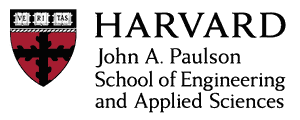

# CS1090A Introduction to Data Science
## Homework 1: A Reproducible Scraping & EDA Pipeline

**Harvard University**<br/>
**Fall 2026**<br/>
**Instructors**: Pavlos Protopapas, Kevin Rader, and Chris Gumb

<hr style="height:2.4pt">

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
import json
import time
import glob
import datetime
from concurrent.futures import ThreadPoolExecutor
from IPython import display

In [3]:
# For calculating total notebook runtime
notebook_start = time.time()

In [4]:
style = '''<style>
h2, h3, h4 {
    background-color: #7efcf5;
    border-left: 5px solid #7ec4fc;
    border-right: 5px solid #7ec4fc;
    padding: 0em;
    color: #1F2937;
}
h3 {
    background-color: #7efcf5;
    border-top: 5px solid #7ec4fc;
    border-left: 5px solid #7ec4fc;
    border-right: 5px solid #7ec4fc;
    padding: 0.5em;
}
div.md {
    border-left: 5px solid #7ec4fc;
    border-right: 5px solid #7ec4fc;
    border-bottom: 5px solid #7ec4fc;
    padding: 0.5em;
}
div.prompt {
    background: #d1ffbd;
    border: thin solid black;
    border-radius: 2px;
    padding: 5px;
    margin: 0.5em 0;
    color: #1F2937;
}
/* A colour on the box does not reach <code> or <a> inside it. JupyterLab's dark
   theme gives inline code background-color: var(--jp-layout-color2) (#424242) and
   colours links #64b5f6, so setting only the box colour would put dark text on a
   dark code background. Code and links outside a box are left alone, where the
   theme's own pairing is already right. */
div.prompt code, div.alert code {
    background: rgba(0, 0, 0, 0.06);
    color: #1F2937;
}
div.prompt a, div.alert a {
    color: #1D4ED8;
}
</style>'''
display.display(display.HTML(style))

## Assignment Overview

You'll build a **reproducible data pipeline** around
[screenboston.com](https://screenboston.com), a site that aggregates movie
screenings from theaters around Boston. You will collect the data (live page +
historical snapshots), structure it with Pandas, enrich it from Wikipedia, use
EDA and visualization to understand it — and finish by making a **data-driven
recommendation** to the theaters themselves.

Think of the assignment is a structured mini-project. Each question tells
you the **goal**, the **required artifact** (file, variable, or figure), and any
**constraints** — how you get there is up to you. Sections 1–2 and the
supplemental notebooks (*MediaWiki API*, *Matplotlib & Seaborn reference*)
demonstrate every technique you'll need.

**The reproducibility theme.** A grader (or future you) should be able to re-run
your notebook and get the *same dataset and results*. Concretely, throughout
this assignment:

- **Guard every fetch** — code that touches the network must first check for a
  cached copy on disk and skip the request if it exists.
- **Derive results from pinned data** — that is, historical Wayback snapshots and cached
  files, not whatever the live web happens to say today.
- You will **submit your small data files** alongside the notebook (see
  Question 10), so your results are reproducible without the network.

**Structure** (10 questions + wrap-up; CS1090A graded out of 95, AC209A out of
100 — see the AC209A section):

1. Acquire the live page (4 pts)
2. Parse HTML into records (10 pts)
3. A reproducible dataset from Wayback snapshots (12 pts)
4. Build and clean a DataFrame (12 pts)
5. Exploratory data analysis (14 pts)
6. Resolve films to Wikipedia page IDs (8 pts)
7. Cache Wikipedia page content to disk (4 pts)
8. Enrich the data and ask a new question (10 pts)
9. **The decision: program Halloween weekend (14 pts)**
10. Reproducibility reflection & data submission (6 pts)
11. Wrap-up (1 pt)
12. **AC209A only:** SQL + concurrency (5 pts — required for AC209A; CS1090A
    students may skip this section entirely)

## Instructions

<div class="prompt" style="background: lightgreen; border: thin solid black; border-radius: 2px; padding: 5px; color: #1F2937;">

**General**
- To submit your notebook and data files, follow the instructions on the Canvas assignment page.
- **CS1090A is graded out of 95; AC209A is graded out of 100.** Three subquestions are marked *AC209A only*: 6a and 7a (concurrency evidence, 1 point each) and 8a (SQL, 3 points). CS1090A students skip those three and lose nothing by doing so — they are required work for AC209A, not extra credit for anyone.
- Plots must be legible and interpretable *without reading the code that generated them*: axis labels, a descriptive title, and a legend where appropriate.
- When asked to interpret a result, explain what it *means* — not what the plot looks like.
- The automated tests are **smoke tests only**: they check that required artifacts exist and have the right shape. Passing them is necessary, not sufficient — most credit is assigned by rubric to your approach, analysis, and writing.
- Your code must be **re-runnable — including offline**: "Restart Kernel and Run All Cells" must complete without error, and given your submitted data files it must complete *without any network access* (this is how it will be graded). 
- Only make network requests when the corresponding cache is empty. Gratuitous re-fetching (of pages you already saved) will lose credit.
- Feel free to add code or markdown cells. Include a written response wherever a question asks for one.
- **Before submitting: Restart Kernel and Run All Cells**, confirm no errors and that all output is visible.

**Use of AI tools**

AI tools — coding agents especially — are part of the modern data science workflow. One principle governs everything: **you are accountable for whatever you submit.** You must understand it, be able to communicate it, and be able to justify it.

- Written interpretations, the Question 9 memo, and the Question 10 reflection must be **your own reasoning in your own words**.
- In Question 10 you will briefly **disclose** how you used AI on this assignment and what you did to verify its output.
- Remember, any understanding you skip here will be paid for later in quizzes & midterms.
</div>

## Question 1: Acquire the live page

<p>Get the current HTML of <a href="https://screenboston.com">screenboston.com</a> and cache it to disk.</p>

<p><b>Why HTML at all?</b> Before scraping any site, look for structured data first — an official API, or the JSON many modern sites load their pages from. screenboston has one: <code>screenboston.com/__data.json</code> serves the current schedule as JSON, and parsing it would be easier than parsing HTML. We parse HTML anyway for one decisive reason: this assignment's dataset is <i>historical</i>, and the past only exists in the Wayback Machine's snapshots of the <i>rendered page</i>.</p>

<div class=prompt>

**Artifact:** the file <code>data/html/screenboston.html</code>.

**Constraints:**
- The fetch must be <b>guarded</b>: make an HTTP request only if the file does not already exist.
- <b>Identify yourself</b>: send a descriptive <code>User-Agent</code> naming the course. Some sites block anonymous default clients.
</div>

<p><b>Note what you just built:</b> this file is the one piece of your dataset that is <i>not</i> reproducible — it captures whatever the site showed on the day you ran this cell. (We'll fix that in Question 3)</p>

In [5]:
# your code here
def fetch_to_cache(url, path):    
    os.makedirs(os.path.dirname(path), exist_ok=True)

    if os.path.exists(path):
        print(f"cached: {path}")
        
    else:
        response = requests.get(
            url,
            headers={
                "User-Agent": "CS1090A-course-exercise/2026 (Harvard; elisasee@college.harvard.edu)"
            },
            timeout=30
        )
        
        response.raise_for_status()
        content_type = response.headers.get("Content-Type", "").lower()
        assert "text/html" in content_type, (
            f"Expected HTML, received {content_type}"
        )
        assert "<html" in response.text.lower(), (
            "Response does not look like an HTML page"
        )
        
        with open(path, "w", encoding="utf-8") as f:
            f.write(response.text)
            
        print(f"fetched: {path}")

    with open(path, encoding="utf-8") as f:
        return f.read()

        
screenboston_url = "https://screenboston.com"
html_file = "data/html/screenboston.html"

html = fetch_to_cache(screenboston_url, html_file)
len(html)


cached: data/html/screenboston.html


233838

In [6]:
grader.check("q1")

q1 results: All test cases passed!

## Question 2: Parse the HTML into records

<p>Turn the page into structured data: one record per screening (a film, at a theater, on a date).</p>

<div class=prompt>

**Artifact:** a list of dictionaries named <code>movies</code>, one per screening, each with <i>exactly</i> these keys:

```python
{'title': 'Monty Python and the Holy Grail',
 'directors': 'Terry Jones, Terry Gilliam',   # plural key, even for one director
 'year': 1975,                                 # int
 'genre': 'Adventure',
 'runtime': '1h 31m',
 'theater': 'Coolidge Corner Theatre',
 'screen_date': '2026-07-11',
 'screen_times': '11:59 PM'}
```

**Constraints:**
- Write your parsing as <b>reusable function(s)</b> that take an HTML string — Question 3 will run them on ~20 more pages.
- Report how many records you extracted and display one example.
- Some listings are missing fields; a record with a <code>None</code> value is fine, but don't let one malformed listing crash the whole parse.
- <b>Never fail silently.</b> Your parser must also report how many listings it <i>failed</i> to parse. A page whose structure has drifted enough to break the parser should announce itself ("parsed 0 of 66 listings") — silent errors cause issues downstream and are a nightmare to debug.
</div>

**Hints:** your browser's *inspect* tool is how you learn the page's structure. Screening dates are not inside each listing — look at what *contains* the listings.

In [7]:
DATE_ID = re.compile(r"^\d{4}-\d{2}-\d{2}$")


def clean_text(tag):
    if tag is None:
        return None
    return tag.get_text(" ", strip=True)


def parse_screenboston(html_text, label="page"):    
    soup = BeautifulSoup(html_text, "html.parser")
    
    movies = []
    failed = 0
    total = 0

    date_sections = soup.find_all("div", id=DATE_ID)

    if not date_sections:
        print(
            "WARNING: no current-layout date sections found; "
            "parsed 0 listings. The page layout may have changed."
        )
        return movies

    for section in date_sections:
        screen_date = section.get("id")

        cards = [
            button
            for button in section.find_all("button")
            if button.select_one("p.big") is not None
        ]

        for card in cards:
            total += 1

            try:
                title_tag = card.select_one("p.big")
                title = clean_text(title_tag)

                if not title:
                    raise ValueError("missing title")

                info_panel = title_tag.parent.parent
                direct_blocks = info_panel.find_all(
                    "div",
                    recursive=False
                )
                lower_block = direct_blocks[-1]

                columns = lower_block.find_all(
                    "div",
                    recursive=False
                )

                if len(columns) < 2:
                    raise ValueError("metadata columns not found")

                left_text = [
                    clean_text(p)
                    for p in columns[0].find_all(
                        "p",
                        recursive=False
                    )
                ]

                right_text = [
                    clean_text(p)
                    for p in columns[1].find_all("p")
                ]

                metadata = next(
                    (
                        text
                        for text in left_text
                        if re.match(r"^\d{4}\s*,", text or "")
                    ),
                    None
                )

                directors = next(
                    (
                        text
                        for text in left_text
                        if text != metadata
                    ),
                    None
                )

                year = None
                genre = None
                runtime = None

                if metadata is not None:
                    parts = [
                        part.strip()
                        for part in metadata.split(",", 2)
                    ]

                    if len(parts) >= 1 and parts[0].isdigit():
                        year = int(parts[0])

                    if len(parts) >= 2:
                        genre = parts[1] or None

                    if len(parts) >= 3:
                        runtime = parts[2] or None

                theater = right_text[0] if right_text else None

                if len(right_text) > 1:
                    screen_times = ", ".join(right_text[1:])
                else:
                    screen_times = None

                movies.append({
                    "title": title,
                    "directors": directors,
                    "year": year,
                    "genre": genre,
                    "runtime": runtime,
                    "theater": theater,
                    "screen_date": screen_date,
                    "screen_times": screen_times
                })

            except Exception as error:
                failed += 1
                print(f"Failed listing {total}: {error}")

    print(
    f"{label}: parsed {len(movies)} of {total} listings; "
    f"{failed} failed"
    )

    return movies

movies = parse_screenboston(html)

print(f"Number of records: {len(movies)}")
print(movies[0])

page: parsed 94 of 94 listings; 0 failed
Number of records: 94
{'title': 'True Stories', 'directors': 'David Byrne', 'year': 1986, 'genre': 'Comedy', 'runtime': '1h 29m', 'theater': 'Coolidge Corner Theatre', 'screen_date': '2026-09-10', 'screen_times': '7:30 PM'}


In [8]:
grader.check("q2")

q2 results: All test cases passed!

## Question 3: A reproducible dataset from Wayback snapshots

<p>The live page only shows the next couple of weeks. The Internet Archive's
<a href="https://archive.org/help/wayback_api.php">Wayback Machine availability API</a> lets you retrieve historical snapshots of the page — and because snapshots are <b>pinned</b>, a dataset built from them is reproducible.</p>

<div class=prompt>

**Artifacts:**
1. Snapshot HTML files saved as <code>data/html/snapshot_YYYYMMDD.html</code> — covering <b>all available snapshots</b> of screenboston.com <b>through September 8, 2026</b>.
2. <code>data/movies.json</code> — the combined list of screening records parsed from <i>every</i> HTML file in <code>data/html/</code> (snapshots + live page), written with the <code>json</code> module.

**Constraints:**
- Both steps must be <b>guarded</b> (i.e., check for existing cache before running) — and guard <b>per file</b>, so an interrupted run resumes instead of restarting (or worse, permanently locking in a partial download).
- <b>The archive spans a site redesign.</b> These snapshots run over two years, and
screenboston.com did not look the same throughout. At least one early snapshot will not
parse with selectors written for today's page. Your parser must <b>say so</b> rather than
quietly return an empty list — that is what "never fail silently" in Q2 was for.
<i>Extracting that page's listings anyway is optional and worth a bonus point</i>; be
warned that the older layout carries no release year at all, so <code>year</code> would
have to be <code>None</code> for those records.
- <b>Expect throttling and handle it.</b> The whole class hits archive.org the same week; you *will* see slow responses or HTTP 429. Check status codes before parsing or saving anything — a cached error page is worse than no cache (since a simple guard can't tell them apart). Sanity-check each saved snapshot (does it parse to a plausible number of listings?).
- Assume any well-formed page covers at least through the end of its snapshot month, and that a day's schedule doesn't change once displayed.
- Don't worry about duplicate screenings across overlapping snapshots — Question 4 deals with them.
- Report which snapshots you found and the total number of records.
</div>

**Hint:** the availability API returns the snapshot *closest* to a timestamp — probing one timestamp per month is a reasonable way to sweep the archive's history. Store your list in `movies` (it should now include records from all pages).

In [9]:
import os
import json
import time
import datetime
import requests

CUTOFF = "20260908"
MANIFEST_FILE = "data/wayback_manifest.json"

os.makedirs("data", exist_ok=True)

CDX_URL = "https://web.archive.org/cdx/search/cdx"

params = [
    ("url", "screenboston.com/"),
    ("output", "json"),
    ("filter", "statuscode:200"),
    ("filter", "mimetype:text/html"),
    ("fl", "timestamp,original,statuscode,digest"),
    ("collapse", "digest"),
    ("from", "2024"),
    ("to", CUTOFF + "235959"),
]

headers = {
    "User-Agent": (
        "CS1090A-course-exercise/2026 "
        "(Harvard; elisasee@college.harvard.edu)"
    )
}

response = None

for attempt in range(6):
    response = requests.get(
        CDX_URL,
        params=params,
        headers=headers,
        timeout=90
    )

    if response.status_code == 200:
        break

    if response.status_code in {429, 500, 502, 503, 504}:
        wait = min(2 ** attempt, 60)
        print(
            f"CDX temporarily unavailable "
            f"({response.status_code}); waiting {wait}s"
        )
        time.sleep(wait)
        continue

    response.raise_for_status()

if response is None or response.status_code != 200:
    raise RuntimeError(
        "Wayback CDX request still failed. Wait a few minutes and rerun."
    )

rows = response.json()

if not rows or rows[0][0] != "timestamp":
    raise ValueError("Unexpected CDX response; manifest was not saved.")

capture_timestamps = [
    row[0]
    for row in rows[1:]
    if len(row) >= 1
]

if not capture_timestamps:
    raise ValueError("CDX returned no Screen Boston captures.")


probe_dates = [
    f"{year}{month:02d}01"
    for year in (2024, 2025, 2026)
    for month in range(1, 13)
    if f"{year}{month:02d}01" <= CUTOFF
]

if CUTOFF not in probe_dates:
    probe_dates.append(CUTOFF)


def timestamp_distance(capture, probe):
    capture_dt = datetime.datetime.strptime(
        capture,
        "%Y%m%d%H%M%S"
    )

    probe_dt = datetime.datetime.strptime(
        probe,
        "%Y%m%d"
    )

    return abs((capture_dt - probe_dt).total_seconds())


captures = {}

for probe in probe_dates:
    closest_timestamp = min(
        capture_timestamps,
        key=lambda timestamp: timestamp_distance(
            timestamp,
            probe
        )
    )

    capture_date = closest_timestamp[:8]

    if capture_date <= CUTOFF:
        captures[capture_date] = {
            "timestamp": closest_timestamp,
            "url": (
                "https://web.archive.org/web/"
                f"{closest_timestamp}id_/"
                "https://screenboston.com/"
            )
        }


manifest_state = {
    "cutoff": CUTOFF,
    "completed_probes": sorted(probe_dates),
    "captures": captures
}

with open(
    MANIFEST_FILE,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        manifest_state,
        file,
        indent=2
    )

snapshot_manifest = {
    date: details["url"]
    for date, details in captures.items()
}

print(
    f"Success: saved {len(snapshot_manifest)} "
    f"snapshot dates to {MANIFEST_FILE}"
)

print(sorted(snapshot_manifest))

Success: saved 30 snapshot dates to data/wayback_manifest.json
['20240328', '20240524', '20240621', '20240803', '20240904', '20240926', '20241101', '20241206', '20250105', '20250131', '20250217', '20250326', '20250428', '20250616', '20250622', '20250813', '20250903', '20250924', '20251021', '20251127', '20251215', '20260123', '20260312', '20260413', '20260513', '20260616', '20260708', '20260721', '20260827', '20260908']


In [10]:
DATE_ID = re.compile(r"^\d{4}-\d{2}-\d{2}$")

RUNTIME_RE = re.compile(
    r"\b(?:\d+\s*h(?:\s*\d+\s*m)?|\d+\s*m)\b",
    flags=re.IGNORECASE
)


def clean_text(tag):
    if tag is None:
        return None

    return tag.get_text(" ", strip=True)


def parse_metadata(text):
    year = None
    genre = None
    runtime = None

    if not text:
        return year, genre, runtime

    parts = [
        part.strip()
        for part in text.split(",")
        if part.strip()
    ]

    if parts and re.fullmatch(r"\d{4}", parts[0]):
        year = int(parts.pop(0))

    if parts and RUNTIME_RE.search(parts[-1]):
        runtime = parts.pop()

    if parts:
        genre = parts[-1]

    return year, genre, runtime


def parse_movie_card(card, screen_date):
    title = clean_text(card.select_one("p.big"))

    if not title:
        raise ValueError("missing title")

    info_panel = card.select_one(r"div.child\:flex-1")

    if info_panel is None:
        raise ValueError("missing information panel")

    columns = info_panel.find_all(
        "div",
        recursive=False
    )

    if len(columns) < 2:
        raise ValueError("expected two information columns")

    left_text = [
        clean_text(p)
        for p in columns[0].find_all(
            "p",
            recursive=False
        )
    ]

    right_text = [
        clean_text(p)
        for p in columns[1].find_all("p")
    ]

    metadata = next(
        (
            value
            for value in left_text
            if re.match(r"^\d{4}\s*,", value or "")
            or RUNTIME_RE.search(value or "")
        ),
        None
    )

    directors = next(
        (
            value
            for value in left_text
            if value and value != metadata
        ),
        None
    )

    year, genre, runtime = parse_metadata(metadata)

    return {
        "title": title,
        "directors": directors,
        "year": year,
        "genre": genre,
        "runtime": runtime,
        "theater": right_text[0] if right_text else None,
        "screen_date": screen_date,
        "screen_times": (
            ", ".join(right_text[1:])
            if len(right_text) > 1
            else None
        ),
    }

In [11]:
def parse_screenboston(html_text, label="page"):
    soup = BeautifulSoup(html_text, "html.parser")

    jobs = []
    layout = "modern"

    date_sections = soup.find_all(
        "div",
        id=DATE_ID
    )

    for section in date_sections:
        screen_date = section.get("id")

        cards = [
            button
            for button in section.find_all("button")
            if button.select_one("p.big") is not None
            and button.select_one(r"div.child\:flex-1") is not None
        ]

        for card in cards:
            jobs.append((screen_date, card))

    if not jobs:
        layout = "legacy"

        page_year = None

        for button in soup.find_all("button"):
            year_match = re.search(
                r"\b(20\d{2})\b",
                clean_text(button) or ""
            )

            if year_match:
                page_year = int(year_match.group(1))
                break

        if page_year is None:
            filename_match = re.search(
                r"snapshot_(\d{4})",
                label
            )

            if filename_match:
                page_year = int(filename_match.group(1))

        if page_year is None:
            print(
                f"{label}: legacy layout found, "
                "but its calendar year could not be determined"
            )
        else:
            legacy_date_tags = soup.select(
                "p.big.col-span-1"
            )

            for date_tag in legacy_date_tags:
                date_text = clean_text(date_tag)

                try:
                    screen_date = datetime.datetime.strptime(
                        f"{date_text} {page_year}",
                        "%a %b %d %Y"
                    ).strftime("%Y-%m-%d")
                except ValueError:
                    print(
                        f"{label}: could not parse legacy "
                        f"date {date_text!r}"
                    )
                    continue

                date_row = date_tag.parent

                legacy_cards = [
                    link
                    for link in date_row.find_all("a")
                    if link.select_one("p.big") is not None
                    and link.select_one(
                        r"div.child\:flex-1"
                    ) is not None
                ]

                for card in legacy_cards:
                    jobs.append((screen_date, card))

    movies = []
    failed = 0

    for screen_date, card in jobs:
        try:
            movie = parse_movie_card(
                card,
                screen_date
            )
            movies.append(movie)

        except Exception as exc:
            failed += 1

            if failed <= 5:
                print(
                    f"{label}: failed to parse one listing: {exc}"
                )

    print(
        f"{label} ({layout} layout): "
        f"parsed {len(movies)} of {len(jobs)} listings; "
        f"{failed} failed"
    )

    return movies

In [12]:
HEADERS = {
    "User-Agent": (
        "CS1090A-course-exercise/2026 "
        "(Harvard; elisasee@college.harvard.edu)"
    )
}

WAYBACK_API = "https://archive.org/wayback/available"
PAGE_URL = "https://screenboston.com/"
CUTOFF = "20260908"
HTML_DIR = "data/html"
MANIFEST_FILE = "data/wayback_manifest.json"
MOVIES_FILE = "data/movies.json"

os.makedirs(HTML_DIR, exist_ok=True)


def get_checked(url, tries=6, **kwargs):
    retryable = {429, 500, 502, 503, 504}

    for attempt in range(tries):
        try:
            response = requests.get(
                url,
                headers=HEADERS,
                timeout=60,
                **kwargs
            )
        except requests.RequestException as error:
            if attempt == tries - 1:
                print(f"  request failed after {tries} tries: {error}")
                return None

            wait = min(2 ** attempt, 60)
            print(f"  network error; waiting {wait}s before retry")
            time.sleep(wait)
            continue

        if response.status_code in retryable:
            if attempt == tries - 1:
                print(
                    f"  still throttled ({response.status_code}) "
                    f"after {tries} tries; skipping for now"
                )
                return None

            retry_after = response.headers.get("Retry-After")
            try:
                wait = float(retry_after)
            except (TypeError, ValueError):
                wait = 2 ** attempt

            wait = min(max(wait, 1), 60)
            print(
                f"  throttled ({response.status_code}); "
                f"waiting {wait:g}s"
            )
            time.sleep(wait)
            continue

        if not response.ok:
            print(f"  HTTP {response.status_code}; not saving this response")
            return None

        return response

    return None


def save_json_atomic(value, path):
    temporary = path + ".tmp"
    with open(temporary, "w", encoding="utf-8") as file:
        json.dump(value, file, indent=2, ensure_ascii=False)
    os.replace(temporary, path)


probe_dates = [
    f"{year}{month:02d}01"
    for year in (2024, 2025, 2026)
    for month in range(1, 13)
    if f"{year}{month:02d}01" <= CUTOFF
]
if CUTOFF not in probe_dates:
    probe_dates.append(CUTOFF)

if os.path.isfile(MANIFEST_FILE):
    with open(MANIFEST_FILE, encoding="utf-8") as file:
        manifest_state = json.load(file)

    if not (
        isinstance(manifest_state, dict)
        and manifest_state.get("cutoff") == CUTOFF
        and isinstance(manifest_state.get("completed_probes"), list)
        and isinstance(manifest_state.get("captures"), dict)
    ):
        print("Old/incomplete manifest format found; rebuilding its index.")
        manifest_state = {
            "cutoff": CUTOFF,
            "completed_probes": [],
            "captures": {}
        }
else:
    manifest_state = {
        "cutoff": CUTOFF,
        "completed_probes": [],
        "captures": {}
    }

completed_probes = set(manifest_state["completed_probes"])

for probe in probe_dates:
    if probe in completed_probes:
        continue

    print(f"probing {probe} ...")
    response = get_checked(
        WAYBACK_API,
        params={"url": PAGE_URL, "timestamp": probe}
    )

    if response is None:
        continue

    try:
        payload = response.json()
    except ValueError:
        print("  response was not JSON; not caching it")
        continue

    closest = payload.get("archived_snapshots", {}).get("closest")
    if closest and closest.get("available"):
        timestamp = closest.get("timestamp", "")
        replay_url = closest.get("url", "")

        if timestamp[:8] <= CUTOFF and replay_url:
            replay_url = re.sub(r"^http://", "https://", replay_url)
            manifest_state["captures"][timestamp[:8]] = {
                "timestamp": timestamp,
                "url": replay_url
            }

    completed_probes.add(probe)
    manifest_state["completed_probes"] = sorted(completed_probes)
    save_json_atomic(manifest_state, MANIFEST_FILE)
    time.sleep(0.25)

unfinished_probes = sorted(set(probe_dates) - completed_probes)
if unfinished_probes:
    print(
        f"{len(unfinished_probes)} probe(s) were throttled. "
        "Rerun this cell later; completed work is checkpointed."
    )

snapshot_manifest = {
    date: details["url"]
    for date, details in manifest_state["captures"].items()
}

print(f"{len(snapshot_manifest)} unique snapshot dates found")

for date, url in sorted(snapshot_manifest.items()):
    path = os.path.join(HTML_DIR, f"snapshot_{date}.html")

    if os.path.isfile(path):
        print(f"cached: {path}")
        continue

    print(f"fetching snapshot {date} ...")
    response = get_checked(url)
    if response is None:
        continue

    response.encoding = response.apparent_encoding or "utf-8"
    snapshot_html = response.text

    if "<html" not in snapshot_html.lower():
        print(f"  {date}: response is not HTML; not saved")
        continue

    preview = parse_screenboston(
        snapshot_html,
        label=f"snapshot_{date}.html"
    )
    if not preview:
        print(f"  {date}: parsed 0 listings; not saved")
        continue

    temporary = path + ".tmp"
    with open(temporary, "w", encoding="utf-8") as file:
        file.write(snapshot_html)
    os.replace(temporary, path)
    print(f"saved: {path} ({len(preview)} listings)")
    time.sleep(0.25)

snapshot_files = sorted(
    glob.glob(
        os.path.join(HTML_DIR, "snapshot_*.html")
    )
)

live_file = os.path.join(
    HTML_DIR,
    "screenboston.html"
)

html_files = snapshot_files.copy()

if os.path.isfile(live_file):
    html_files.append(live_file)
    movies_is_current = (
    os.path.isfile(MOVIES_FILE)
    and html_files
    and os.path.getmtime(MOVIES_FILE)
        >= max(os.path.getmtime(path) for path in html_files)
)

if movies_is_current:
    with open(MOVIES_FILE, encoding="utf-8") as file:
        movies = json.load(file)
    print(f"loaded {len(movies)} cached records from {MOVIES_FILE}")
else:
    movies = []
    for path in html_files:
        with open(path, encoding="utf-8") as file:
            page_html = file.read()
        movies.extend(
            parse_screenboston(page_html, label=os.path.basename(path))
        )

    save_json_atomic(movies, MOVIES_FILE)
    print(f"saved {len(movies)} records to {MOVIES_FILE}")


snapshot_files = sorted(glob.glob(os.path.join(HTML_DIR, "snapshot_*.html")))
missing_dates = sorted(
    set(snapshot_manifest)
    - {
        re.search(r"snapshot_(\d{8})\.html$", path).group(1)
        for path in snapshot_files
        if re.search(r"snapshot_(\d{8})\.html$", path)
    }
)

print(f"\nSnapshots on disk: {len(snapshot_files)}")
print([os.path.basename(path) for path in snapshot_files])
print(f"Total screening records: {len(movies)}")
if missing_dates:
    print(f"Still missing {len(missing_dates)} date(s): {missing_dates}")
    print("Rerun this cell later; existing files will be skipped.")

legacy_rows = [
    movie
    for movie in movies
    if str(movie.get("screen_date", "")).startswith(("2024-03", "2024-04"))
]
print(f"Legacy-layout bonus rows recovered: {len(legacy_rows)}")


30 unique snapshot dates found
cached: data/html/snapshot_20240328.html
cached: data/html/snapshot_20240524.html
cached: data/html/snapshot_20240621.html
cached: data/html/snapshot_20240803.html
cached: data/html/snapshot_20240904.html
cached: data/html/snapshot_20240926.html
cached: data/html/snapshot_20241101.html
cached: data/html/snapshot_20241206.html
cached: data/html/snapshot_20250105.html
cached: data/html/snapshot_20250131.html
cached: data/html/snapshot_20250217.html
cached: data/html/snapshot_20250326.html
cached: data/html/snapshot_20250428.html
cached: data/html/snapshot_20250616.html
cached: data/html/snapshot_20250622.html
cached: data/html/snapshot_20250813.html
cached: data/html/snapshot_20250903.html
cached: data/html/snapshot_20250924.html
cached: data/html/snapshot_20251021.html
cached: data/html/snapshot_20251127.html
cached: data/html/snapshot_20251215.html
cached: data/html/snapshot_20260123.html
cached: data/html/snapshot_20260312.html
cached: data/html/snapshot

In [13]:
legacy_rows = [
    movie
    for movie in movies
    if str(movie.get("screen_date", "")).startswith("2024-03")
    or str(movie.get("screen_date", "")).startswith("2024-04")
]

print(f"Legacy rows recovered: {len(legacy_rows)}")
display.display(legacy_rows)

Legacy rows recovered: 2


[{'title': 'Blue Giant',
  'directors': 'Yuzuru Tachikawa',
  'year': None,
  'genre': 'Thriller',
  'runtime': '2h',
  'theater': 'Museum of Fine Arts',
  'screen_date': '2024-03-30',
  'screen_times': '7:00 PM'},
 {'title': 'Perfect Days',
  'directors': 'Wim Wenders',
  'year': None,
  'genre': 'Thriller',
  'runtime': '2h 3m',
  'theater': 'Museum of Fine Arts',
  'screen_date': '2024-04-05',
  'screen_times': '7:00 PM'}]

In [14]:
# Display info about snapshots and parse results
print("Snapshots on disk:")
print(sorted(os.path.basename(f) for f in glob.glob('data/html/snapshot_*')))
print(f"{len(movies)} total screening records across all HTML files.")

Snapshots on disk:
['snapshot_20240328.html', 'snapshot_20240524.html', 'snapshot_20240621.html', 'snapshot_20240803.html', 'snapshot_20240904.html', 'snapshot_20240926.html', 'snapshot_20241101.html', 'snapshot_20241206.html', 'snapshot_20250105.html', 'snapshot_20250131.html', 'snapshot_20250217.html', 'snapshot_20250326.html', 'snapshot_20250428.html', 'snapshot_20250616.html', 'snapshot_20250622.html', 'snapshot_20250813.html', 'snapshot_20250903.html', 'snapshot_20250924.html', 'snapshot_20251021.html', 'snapshot_20251127.html', 'snapshot_20251215.html', 'snapshot_20260123.html', 'snapshot_20260312.html', 'snapshot_20260413.html', 'snapshot_20260513.html', 'snapshot_20260616.html', 'snapshot_20260708.html', 'snapshot_20260721.html', 'snapshot_20260827.html', 'snapshot_20260908.html']
2695 total screening records across all HTML files.


In [15]:
grader.check("q3")

q3 results: All test cases passed!

## Question 4: Build and clean a DataFrame

<div class=prompt>

**Artifact:** a DataFrame <code>df</code> built from <code>data/movies.json</code>, satisfying:

1. **No duplicate rows** (rows where *all* values match — overlapping snapshots create many). Report how many rows you dropped and how many remain.
2. A **missingness audit**: NaN counts per column, and a display of the rows containing at least one NaN (or confirmation there are none).
3. **A dtype on each column that matches what the column holds**: <code>screen_date</code> as a datetime type, <code>runtime</code> as a timedelta type.
4. Sorted by ascending <code>screen_date</code>.

<b>Verify as you go</b> — after each transform, check what you actually produced (<code>.shape</code>, <code>.dtypes</code>, a spot-check of rows). Whether you or an 'assistant' wrote the code, the sign-off on the result is your responsibility.

Then use the clean frame to create:

5. A table of **screenings per theater per calendar month** (rows = month, columns = theater; restrict columns to the 6 busiest theaters). Then, in one or two sentences: what do you notice?
</div>

In [16]:

with open("data/movies.json", encoding="utf-8") as file:
    raw_movies = json.load(file)

df = pd.DataFrame(raw_movies)

print("Initial shape:", df.shape)
display.display(df.head())
print("\nInitial dtypes:")
print(df.dtypes)

rows_before = len(df)

# Remove completely identical rows from overlapping snapshots.
df = df.drop_duplicates().copy()

rows_after_exact = len(df)
exact_duplicates_dropped = rows_before - rows_after_exact

# This defines one screening unit.
screening_key = [
    "title",
    "year",
    "directors",
    "theater",
    "screen_date"
]

# If an older and newer snapshot disagree, keep the newer version.
revised_duplicates = df.duplicated(
    subset=screening_key,
    keep="last"
).sum()

df = (
    df
    .drop_duplicates(
        subset=screening_key,
        keep="last"
    )
    .copy()
)

print(
    "Exact duplicate rows dropped:",
    exact_duplicates_dropped
)
print(
    "Older schedule versions replaced:",
    revised_duplicates
)
print("Rows remaining:", len(df))

df["screen_date"] = pd.to_datetime(
    df["screen_date"],
    errors="coerce"
)

df["runtime"] = pd.to_timedelta(
    df["runtime"],
    errors="coerce"
)

df["year"] = pd.to_numeric(
    df["year"],
    errors="coerce"
).astype("Int64")

text_columns = [
    "title",
    "directors",
    "genre",
    "theater",
    "screen_times"
]

for column in text_columns:
    df[column] = df[column].astype("string")

df = (
    df
    .sort_values("screen_date")
    .reset_index(drop=True)
)

missing_counts = df.isna().sum()

print("\nMissing values per column:")
display.display(missing_counts.to_frame("missing_count"))

rows_with_missing_values = df[
    df.isna().any(axis=1)
]

print(
    f"Rows containing at least one missing value: "
    f"{len(rows_with_missing_values)}"
)

if len(rows_with_missing_values) > 0:
    display.display(rows_with_missing_values)
else:
    print("No rows contain missing values.")


print("\nFinal shape:", df.shape)

print("\nFinal dtypes:")
print(df.dtypes)

print("\nFirst rows after sorting:")
display.display(df.head())

print("\nLast rows after sorting:")
display.display(df.tail())

print("\nDuplicate rows remaining:")
print(df.duplicated().sum())

Initial shape: (2695, 8)


,title,directors,year,genre,runtime,theater,screen_date,screen_times
0,Blue Giant,Yuzuru Tachikawa,NaN,Thriller,2h,Museum of Fine Arts,2024-03-30,7:00 PM
1,Perfect Days,Wim Wenders,NaN,Thriller,2h 3m,Museum of Fine Arts,2024-04-05,7:00 PM
2,Ghost Dog: The Way of the Samurai,Jim Jarmusch,1999.0,Crime,1h 56m,The Brattle,2024-05-24,"4:00 PM, 9:00 PM"
3,Stray Dog,Akira Kurosawa,1949.0,Crime,2h 2m,The Brattle,2024-05-24,6:30 PM
4,Big Trouble in Little China,John Carpenter,1986.0,Comedy,1h 40m,Coolidge Corner Theatre,2024-05-24,11:59 PM



Initial dtypes:
title               str
directors           str
year            float64
genre               str
runtime             str
theater             str
screen_date         str
screen_times        str
dtype: object
Exact duplicate rows dropped: 357
Older schedule versions replaced: 3
Rows remaining: 2335

Missing values per column:


,missing_count
title,0
directors,0
year,2
genre,8
runtime,0
theater,0
screen_date,0
screen_times,0


Rows containing at least one missing value: 10


...


Final shape: (2335, 8)

Final dtypes:
title                    string
directors                string
year                      Int64
genre                    string
runtime         timedelta64[us]
theater                  string
screen_date      datetime64[us]
screen_times             string
dtype: object

First rows after sorting:


,title,directors,year,genre,runtime,theater,screen_date,screen_times
0,Blue Giant,Yuzuru Tachikawa,<NA>,Thriller,0 days 02:00:00,Museum of Fine Arts,2024-03-30,7:00 PM
1,Perfect Days,Wim Wenders,<NA>,Thriller,0 days 02:03:00,Museum of Fine Arts,2024-04-05,7:00 PM
2,Ghost Dog: The Way of the Samurai,Jim Jarmusch,1999,Crime,0 days 01:56:00,The Brattle,2024-05-24,"4:00 PM, 9:00 PM"
3,Stray Dog,Akira Kurosawa,1949,Crime,0 days 02:02:00,The Brattle,2024-05-24,6:30 PM
4,Big Trouble in Little China,John Carpenter,1986,Comedy,0 days 01:40:00,Coolidge Corner Theatre,2024-05-24,11:59 PM



Last rows after sorting:


,title,directors,year,genre,runtime,theater,screen_date,screen_times
2330,Häxan,Benjamin Christensen,1922,Documentary,0 days 01:45:00,Coolidge Corner Theatre,2026-09-29,7:00 PM
2331,Sunrise: A Song of Two Humans,F. W. Murnau,1927,Drama,0 days 01:34:00,The Brattle,2026-09-29,6:30 PM
2332,HÃ¤xan,Benjamin Christensen,1922,Documentary,0 days 01:45:00,Coolidge Corner Theatre,2026-09-29,7:00 PM
2333,Nostalgia,Andrei Tarkovsky,1983,Drama,0 days 02:05:00,Coolidge Corner Theatre,2026-09-30,7:00 PM
2334,Diva,Jean-Jacques Beineix,1981,Action,0 days 01:57:00,The Brattle,2026-09-30,8:00 PM



Duplicate rows remaining:
0


In [17]:
top_six_theaters = (
    df["theater"]
    .value_counts()
    .head(6)
    .index
)

print("Six busiest theaters:")
print(top_six_theaters.tolist())


monthly_theater_table = (
    df.loc[df["theater"].isin(top_six_theaters)]
    .assign(
        month=lambda frame:
            frame["screen_date"].dt.to_period("M")
    )
    .groupby(
        ["month", "theater"],
        observed=True
    )
    .size()
    .unstack(fill_value=0)
    .reindex(columns=top_six_theaters)
)

monthly_theater_table.index.name = "Calendar month"
monthly_theater_table.columns.name = "Theater"

display.display(monthly_theater_table)

Six busiest theaters:
['The Brattle', 'Coolidge Corner Theatre', 'Harvard Film Archive', 'Somerville Theatre', 'West Newton Cinema', 'Museum of Fine Arts']


Theater,The Brattle,Coolidge Corner Theatre,Harvard Film Archive,Somerville Theatre,West Newton Cinema,Museum of Fine Arts
Calendar month,,,,,,
2024-03,0,0,0,0,0,1
2024-04,0,0,0,0,0,1
2024-05,18,8,0,3,0,3
2024-06,49,24,0,10,1,9
2024-07,6,24,0,1,0,0
2024-08,43,25,0,25,2,1
2024-09,38,35,26,13,8,1
2024-10,55,39,26,15,0,3
2024-11,36,28,22,4,1,2


*your answer here*

In [18]:
grader.check("q4")

q4 results: All test cases passed!

## Question 5: Exploratory data analysis

Every visualization needs: labeled axes, descriptive title, and a written interpretation of what it *means*.
These are relatively simple visualizations. You should really try writing them yourself.

(Note: "Screening" refers to one row of the `df`.)

### 5.1 Longest films

Display the 10 longest reported runtimes (rows, descending).

Then, in one or two sentences: what are these longest entries, and what does that tell you about what the `runtime` column is measuring?

In [19]:
# your code here
longest= (
    df.loc[
        df["runtime"].notna(),
        ["title","runtime","theater","screen_date"]
        ]
    .sort_values("runtime",ascending=False)
    .head(10)
        
)
longest

,title,runtime,theater,screen_date
1762,51st Annual Boston Science Fiction Film Marathon,1 days 00:00:00,Somerville Theatre,2026-02-15
839,Boston Sci-Fi Film Festival Marathon,1 days 00:00:00,Somerville Theatre,2025-02-16
2237,Marathon '77,0 days 13:00:00,Harvard Film Archive,2026-09-12
1808,The Lord of the Rings Trilogy,0 days 12:45:00,Coolidge Corner Theatre,2026-03-22
1831,The Lord of the Rings Trilogy,0 days 12:45:00,Coolidge Corner Theatre,2026-03-29
1006,The Lord of the Rings Trilogy,0 days 12:45:00,Coolidge Corner Theatre,2025-05-04
1477,24th Halloween Horror Marathon,0 days 12:00:00,Coolidge Corner Theatre,2025-10-25
518,23rd Halloween Horror Marathon,0 days 12:00:00,Coolidge Corner Theatre,2024-10-26
1542,GODZILLATHON,0 days 11:40:00,Somerville Theatre,2025-11-08
1884,Satantango,0 days 07:12:00,Harvard Film Archive,2026-04-25


the longest ones are marathons and trilogies e.g. the sci-fi film marathon. Runtime is the total duraiton of the screening event not just the runtime of a single movie/film. FOr example it is a 1 day film destival or the almost 6 hour triple feature of malkovich,malkovich,malkovich.

### 5.2 Screening counts

Side-by-side subplots with a shared y-axis: screenings by theater, and screenings by genre.

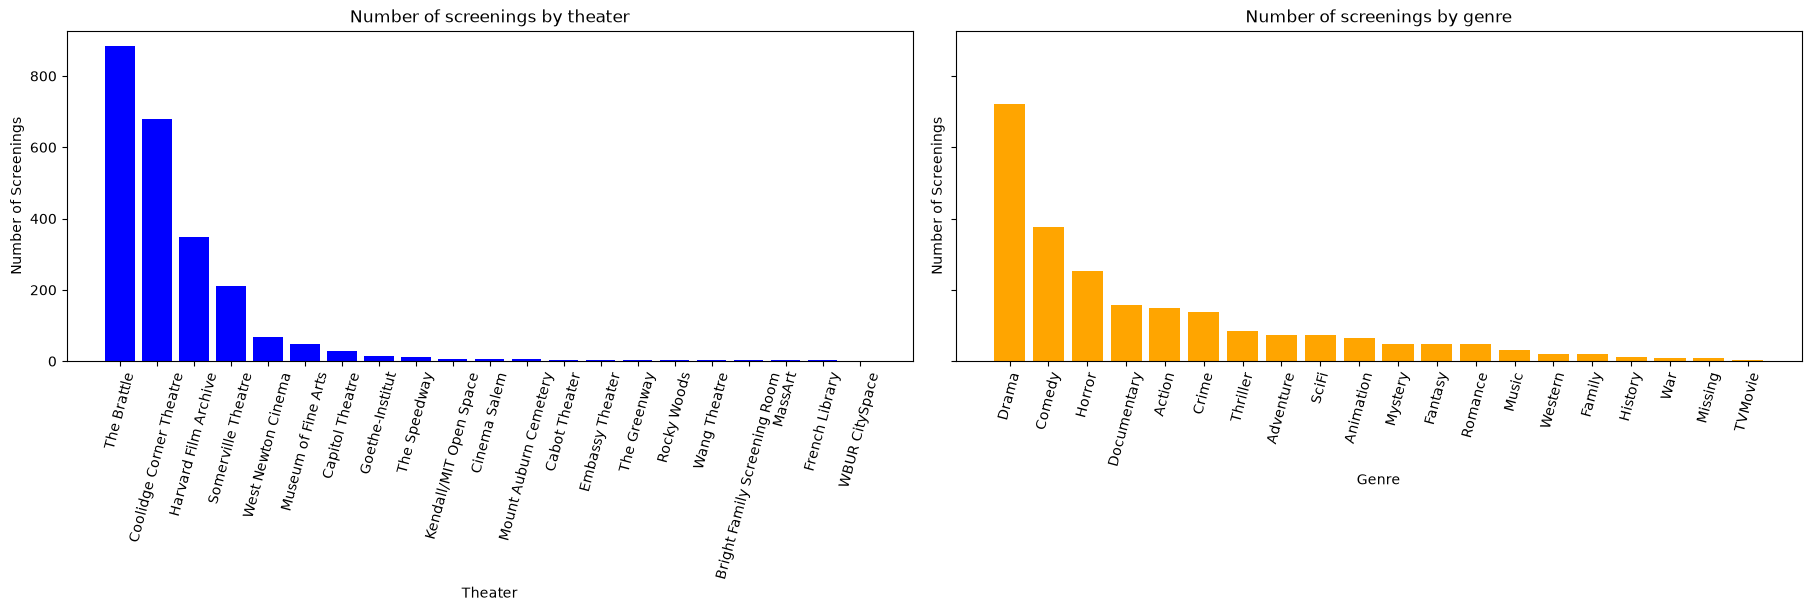

In [20]:
# your code here
theater_count = df["theater"].value_counts()
genre_count=df["genre"].fillna("Missing").value_counts()

fig,axes = plt.subplots(
    1,
    2,
    figsize=(18,6),
    sharey=True,
    constrained_layout=True
)

axes[0].bar(
    theater_count.index,
    theater_count.values,
    color="blue"
)
axes[0].set_title("Number of screenings by theater")
axes[0].set_xlabel("Theater")
axes[0].set_ylabel("Number of Screenings")
axes[0].tick_params(axis="x",rotation=75)

axes[1].bar(
    genre_count.index,
    genre_count.values,
    color="orange"
)
    
axes[1].set_title("Number of screenings by genre")
axes[1].set_xlabel("Genre")
axes[1].set_ylabel("Number of Screenings")
axes[1].tick_params(axis="x", rotation=75)

plt.show()                
        

here we see Brattle and Coolidge Corner make up most of the screening listings. this is a lot larger than the 3rd place )harvard film archive almost 2x more). cabot theater and those on its right, especially french library barely make up any screenings. Drama comedy and horror make up the top 3 genre's for screening with drama being a lot larger than the other categories (looks like 2x more than any of the rest).

### 5.3 Film vintage

A pair of plots showing the distribution of release `year`, overall and broken out by theater (your choice of plot types, but justify the choice).

implausible excluded from plots
                                                  title  year  \
2160  Wicked VHS presents: A Secret Summer Camp Slasher  6666   
2177  Wicked VHS presents: A Secret Summer Camp Slas...  6666   
2238   Mass Mini Con presents: A Mutant Mystery Movie 3  6666   

                      theater  
2160  Coolidge Corner Theatre  
2177  Coolidge Corner Theatre  
2238  Coolidge Corner Theatre  


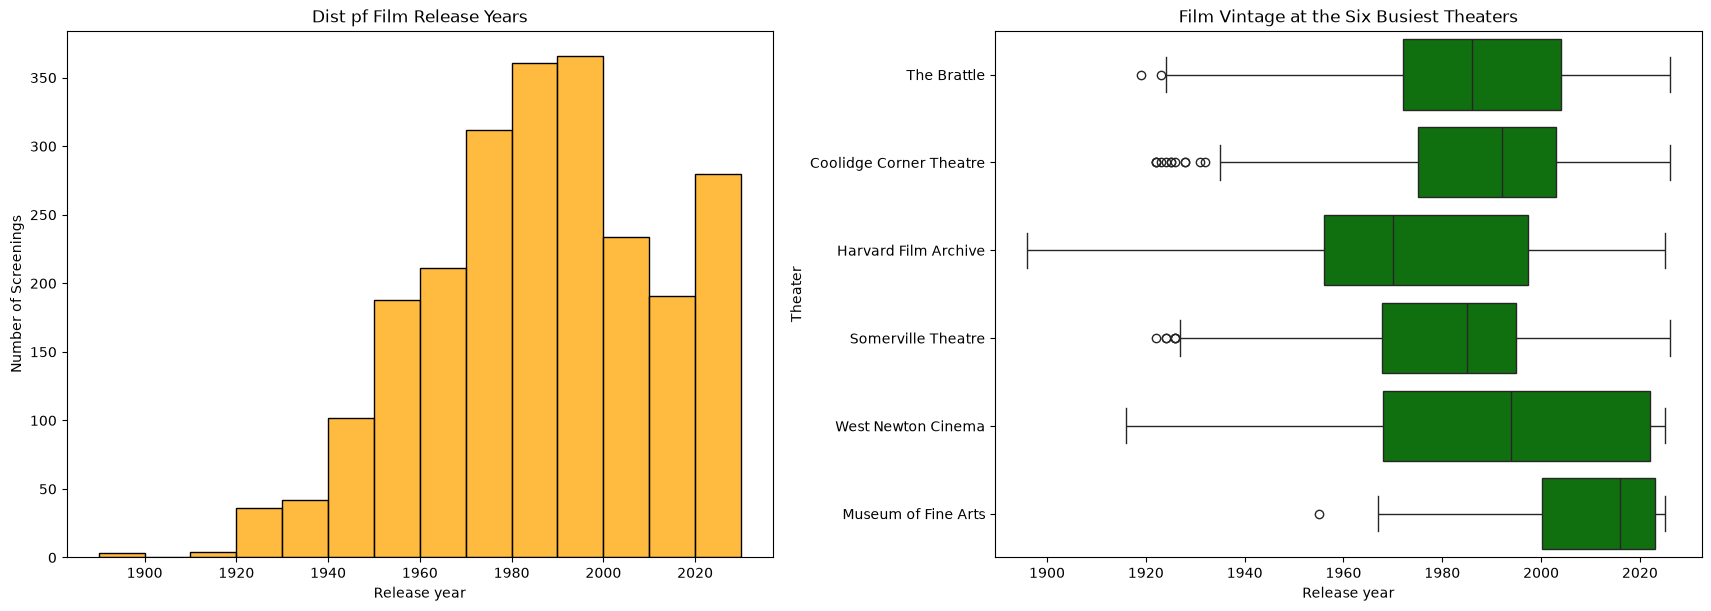

In [21]:
# your code here
valid_mask=(
    df["year"].notna()
    & df["year"].between(1888,int(df["screen_date"].dt.year.max()))
)

invalid_rows = df.loc[
    df["year"].notna() & - valid_mask,
    ['title','year','theater']
]

print('implausible excluded from plots')
print(invalid_rows)

years =df.loc[valid_mask].copy()
min_year=int(years["year"].min())
max_year=int(years["year"].max())

first_bin = (min_year // 10) * 10
last_bin = ((max_year // 10) + 2) * 10
decade_bins = list(range(first_bin, last_bin, 10))

fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, 6),
    constrained_layout=True
)

sns.histplot(
    data=years,
    x="year",
    bins=decade_bins,
    ax=axes[0],
    color="orange"
)
axes[0].set_title("Dist pf Film Release Years")
axes[0].set_xlabel("Release year")
axes[0].set_ylabel("Number of Screenings")

top_six = df["theater"].value_counts().head(6).index

sns.boxplot(
    data=years.loc[years["theater"].isin(top_six)],
    x="year",
    y="theater",
    order=top_six,
    ax=axes[1],
    color="green"
)
axes[1].set_title("Film Vintage at the Six Busiest Theaters")
axes[1].set_xlabel("Release year")
axes[1].set_ylabel("Theater")

plt.show()

histogram shows the overall distribution of how screenings are split across relese decades. we see most releases are from 1970-2000, with is dropping back but not to levels as low as the start 

the boxplots help show the medians and spreads so it is easier to compare
WE can see the harvard film archive has the oldest programming in general while MFA has newer median release years
removing implausible years helps prevent axes distortion making it clearer

### 5.4 One custom question

Pose a question of your own about the screening data and answer it with an appropriate plot whose *type differs* from those you used above. State the question, your approach, the plot, and your interpretation.

,month_number,horror_share,total_screenings
0,1,0.10084,119
1,2,0.061111,180
2,3,0.140741,135
3,4,0.047619,105
4,5,0.086486,185
5,6,0.164384,219
6,7,0.144828,145
7,8,0.068493,292
8,9,0.073171,410
9,10,0.290456,241


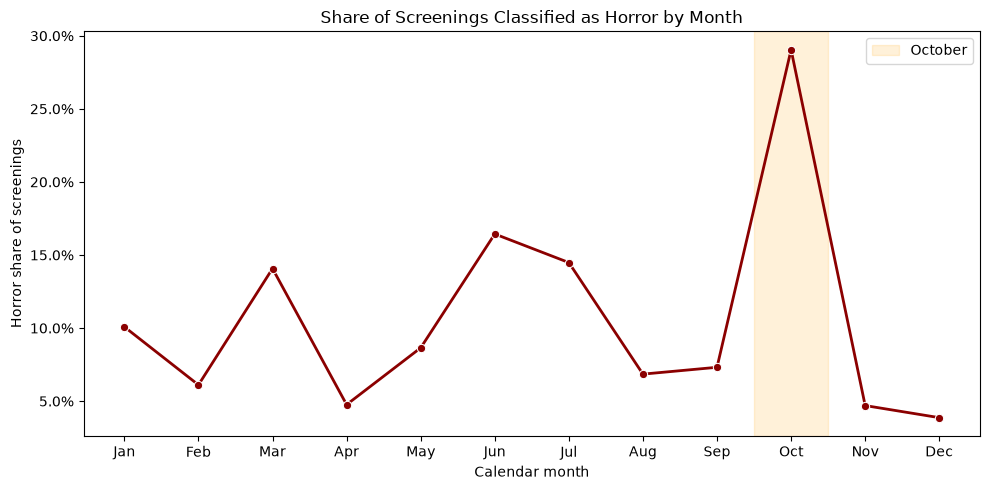

In [22]:
from matplotlib.ticker import PercentFormatter

monthly_horror = (
    df.assign(
        month_number=df["screen_date"].dt.month,
        is_horror=df["genre"].fillna("").eq("Horror")
    )
    .groupby("month_number")
    .agg(
        horror_share=("is_horror", "mean"),
        total_screenings=("title", "size")
    )
    .reindex(range(1, 13))
    .reset_index()
)

month_labels = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

display.display(monthly_horror)

fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=monthly_horror,
    x="month_number",
    y="horror_share",
    marker="o",
    linewidth=2,
    color="darkred",
    ax=ax
)

ax.set_xticks(
    range(1, 13),
    month_labels
)

ax.yaxis.set_major_formatter(
    PercentFormatter(1)
)

ax.set_title(
    "Share of Screenings Classified as Horror by Month"
)
ax.set_xlabel("Calendar month")
ax.set_ylabel("Horror share of screenings")

# Visually mark October.
ax.axvspan(
    9.5,
    10.5,
    color="orange",
    alpha=0.15,
    label="October"
)

ax.legend()
plt.tight_layout()
plt.show()

Given horror makes a fair amount of screenings at the more commercial/popular seeming ones I wanted to see if Halloween (october or so) also had a larger share of screenings of horror.

Thus I asked the quesiton of if horror makes up a larger share of screenings near halloween.

to test this I got the month of every screening data and categorized the greening with a categorical variable of horror or not horror (nominal) then I got the percent of screenings as horror per month, combining this across years
I then got % instead of raw counts as the archive has different # of data for each month and this might not be every movie screened

I used a lineplot as the months have a chronological order (categorical ordinal) and I wanted to show how the proportion chagne through the year. it is worth remembering though like in the bike share example jan and december are close 

I found october has the greatest horror share just under 30%, but march amd june interestingly also see spikes suggesting theaters do have more around halloween however this is just collected listings instead of every screening that occuered ever.

### 5.5 Critique a chart

The provided cell below draws a chart from *your* data, exactly as an over-eager assistant might. It runs without error and looks polished. In a short written answer: what claim does it make, in what specific ways is it misleading, and how would you redraw it so that the visual comparison matches the numbers? (This is the skill the whole module turns on: the tools can draw anything; *you* sign off on what a chart says.)

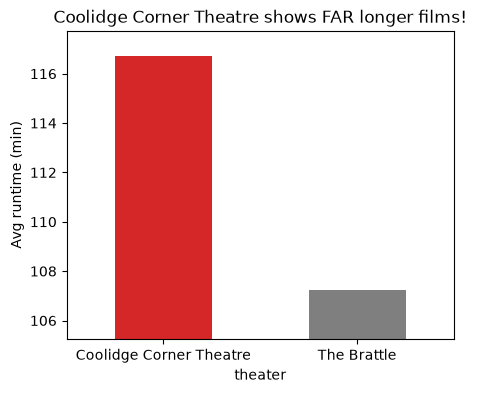

Means: {'Coolidge Corner Theatre': 116.7, 'The Brattle': 107.2}


In [23]:
# --- 5. PROVIDED CELL: do not edit. Critique the chart this draws. ----------
_rt = df.dropna(subset=["runtime"]).copy()
_rt["runtime_min"] = _rt["runtime"].dt.total_seconds() / 60
_top2 = _rt["theater"].value_counts().head(2).index
_means = _rt[_rt["theater"].isin(_top2)].groupby("theater")["runtime_min"].mean()

fig, ax = plt.subplots(figsize=(5, 4))
_means.plot(kind="bar", ax=ax, color=["C3", "C7"], rot=0)
ax.set_ylim(_means.min() - 2, _means.max() + 1)   # <- look closely
ax.set_ylabel("Avg runtime (min)")
ax.set_title(f"{_means.idxmax()} shows FAR longer films!")
plt.show()
print("Means:", _means.round(1).to_dict())

this chart is misleading as the axes starts at 104 not 0, making a 10 minute differnece in the average run time look massive, in reality is is 116.7 vs 107.2 which doesn't really constitute a "Far longer film".  to fix this the chart should have a non-truncated y-axis with a zero-based bar instead.

additionally mean itself may also not represent a typical screening as it may be influenced by unusually long marathons or multi-film events which drags the mean up.a zero-based bar chart with means labelled and a boxplot or other way of showing the median as well can help us better see what the typical film looks like 

## Question 6: Resolve films to Wikipedia page IDs

<p>To enrich our data we need a <b>stable identifier</b> for each film's Wikipedia article. Query the <a href="https://www.mediawiki.org/wiki/API:Main_page">MediaWiki API</a> directly with <code>requests</code> — the numeric <code>pageid</code> is permanent even when article titles change. The <i>MediaWiki API</i> supplemental notebook walks through everything you need.</p>

<div class=prompt>

**Artifact:** a <code>wiki_id</code> column on <code>df</code> (the film's numeric pageid, or <code>NaN</code> when you can't resolve one confidently).

**Constraints:**
- Query each <b>unique film</b> once — not once per screening row.
- Cache your resolved IDs to disk (e.g. a CSV) so re-runs make <b>zero</b> lookup requests.
- Be polite: identify yourself with a User-Agent and handle rate-limiting (HTTP 429 / <code>maxlag</code>) gracefully. Sustained one-search-per-film traffic <i>will</i> get you throttled — plan your request budget.
- Report your coverage (share of screenings with a resolved ID) and show a few films you failed to match — what, if anything, do the misses have in common?

**AC209A (required; CS1090A optional):** parallelize whatever per-film requests remain with a small thread pool (max ~4 workers).
</div>

**Hint (request budget):** film articles follow strong title conventions — <i>"Title (YEAR film)"</i>, <i>"Title (film)"</i>, or just <i>"Title"</i>. The API's <code>action=query&titles=a|b|c</code> form checks up to <b>50 exact titles per request</b> (add <code>redirects=1</code>), which resolves most films in a handful of requests; full-text <code>search</code> is then only needed as a fallback for the stragglers. See the MediaWiki supplemental notebook.

In [24]:
from pathlib import Path
import os
import time
import requests
import pandas as pd

WIKI_API_URL = "https://en.wikipedia.org/w/api.php"
WIKI_CACHE_PATH = Path("data") / "wiki_ids.csv"

wiki_id_cache = Path("data") / "wiki_ids.csv"
wiki_id_cache.parent.mkdir(parents=True, exist_ok=True)

WIKI_CACHE_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

WIKI_HEADERS = {
    "User-Agent": (
        "CS1090A-course-exercise/2026 "
        "(Harvard student project)"
    )
}

CACHE_COLUMNS = [
    "film_key",
    "title",
    "year",
    "wiki_id",
    "wiki_title",
    "match_method"
]


def chunked(values, size=50):
    for start in range(0, len(values), size):
        yield values[start:start + size]


def save_wiki_cache(frame):
    frame = frame.reindex(columns=CACHE_COLUMNS).copy()

    frame = frame.drop_duplicates(
        subset="film_key",
        keep="last"
    )

    frame["wiki_id"] = pd.to_numeric(
        frame["wiki_id"],
        errors="coerce"
    ).astype("Int64")

    temporary_path = WIKI_CACHE_PATH.with_name(
        WIKI_CACHE_PATH.name + ".tmp"
    )

    frame.to_csv(
        temporary_path,
        index=False
    )

    temporary_path.replace(WIKI_CACHE_PATH)


def wiki_request(parameters, tries=6):
    parameters = {
        "format": "json",
        "formatversion": 2,
        "maxlag": 5,
        **parameters
    }

    retryable_statuses = {
        429,
        500,
        502,
        503,
        504
    }

    for attempt in range(tries):
        try:
            response = requests.post(
                WIKI_API_URL,
                data=parameters,
                headers=WIKI_HEADERS,
                timeout=60
            )

        except requests.RequestException as error:
            if attempt == tries - 1:
                raise RuntimeError(
                    "Wikipedia request failed after all retries."
                ) from error

            wait = min(2 ** attempt, 60)

            print(
                f"Network error; waiting {wait}s before retry"
            )

            time.sleep(wait)
            continue

        if response.status_code in retryable_statuses:
            if attempt == tries - 1:
                raise RuntimeError(
                    f"Wikipedia returned HTTP "
                    f"{response.status_code} after all retries."
                )

            try:
                wait = float(
                    response.headers.get("Retry-After")
                )
            except (TypeError, ValueError):
                wait = 2 ** attempt

            wait = min(max(wait, 1), 60)

            print(
                f"Wikipedia returned "
                f"{response.status_code}; waiting {wait:g}s"
            )

            time.sleep(wait)
            continue

        response.raise_for_status()

        try:
            payload = response.json()
        except ValueError as error:
            if attempt == tries - 1:
                raise RuntimeError(
                    "Wikipedia returned a non-JSON response."
                ) from error

            wait = min(2 ** attempt, 60)

            print(
                f"Non-JSON response; waiting {wait}s"
            )

            time.sleep(wait)
            continue

        api_error = payload.get("error", {})

        if api_error.get("code") == "maxlag":
            if attempt == tries - 1:
                raise RuntimeError(
                    "Wikipedia remained overloaded "
                    "after all retries."
                )

            wait = min(2 ** attempt, 60)

            print(
                f"Wikipedia maxlag; waiting {wait}s"
            )

            time.sleep(wait)
            continue

        return payload

    raise RuntimeError(
        "Wikipedia request unexpectedly failed."
    )


def exact_title_query(titles):
    payload = wiki_request({
        "action": "query",
        "titles": "|".join(titles),
        "redirects": 1,
        "prop": "pageprops|extracts",
        "exintro": 1,
        "explaintext": 1,
        "exsentences": 2
    })

    query = payload.get("query", {})

    aliases = {
        title: title
        for title in titles
    }

    for item in query.get("normalized", []):
        aliases[item["from"]] = item["to"]

    for item in query.get("redirects", []):
        aliases[item["from"]] = item["to"]

    pages_by_title = {
        page.get("title"): page
        for page in query.get("pages", [])
        if page.get("pageid") is not None
    }

    results = {}

    for original_title in titles:
        current_title = original_title
        visited = set()

        while (
            current_title not in visited
            and aliases.get(
                current_title,
                current_title
            ) != current_title
        ):
            visited.add(current_title)
            current_title = aliases[current_title]

        page = pages_by_title.get(current_title)

        if page is not None:
            results[original_title] = page

    return results


def usable_film_page(page, bare_title=False):
    if page is None:
        return False

    if page.get("pageid") is None:
        return False

    if page.get("ns", 0) != 0:
        return False

    page_title = str(
        page.get("title", "")
    ).casefold()

    if page_title.endswith("(disambiguation)"):
        return False

    if "disambiguation" in page.get(
        "pageprops",
        {}
    ):
        return False

    if not bare_title:
        return True

    # Bare titles can refer to non-film subjects.
    article_text = (
        str(page.get("title", ""))
        + " "
        + str(page.get("extract", ""))
    ).casefold()

    film_terms = (
        " film",
        "documentary",
        "motion picture"
    )

    return any(
        term in article_text
        for term in film_terms
    )


in_memory_cache = globals().get("wiki_cache")

cache_parts = []

if WIKI_CACHE_PATH.is_file():
    try:
        disk_cache = pd.read_csv(
            WIKI_CACHE_PATH
        )

        if set(CACHE_COLUMNS).issubset(
            disk_cache.columns
        ):
            cache_parts.append(
                disk_cache[CACHE_COLUMNS]
            )
        else:
            print(
                "Ignoring an old cache with "
                "an incompatible format."
            )

    except pd.errors.EmptyDataError:
        pass

if (
    isinstance(in_memory_cache, pd.DataFrame)
    and set(CACHE_COLUMNS).issubset(
        in_memory_cache.columns
    )
):
    cache_parts.append(
        in_memory_cache[CACHE_COLUMNS].copy()
    )

    print(
        "Recovered Wikipedia results "
        "from the previous failed run."
    )

if cache_parts:
    wiki_cache = pd.concat(
        cache_parts,
        ignore_index=True
    )

    wiki_cache = wiki_cache.drop_duplicates(
        "film_key",
        keep="last"
    )
else:
    wiki_cache = pd.DataFrame(
        columns=CACHE_COLUMNS
    )

wiki_cache = wiki_cache.reindex(
    columns=CACHE_COLUMNS
)

wiki_cache["wiki_id"] = pd.to_numeric(
    wiki_cache["wiki_id"],
    errors="coerce"
).astype("Int64")

if not wiki_cache.empty:
    wiki_cache["film_key"] = (
        wiki_cache["film_key"].astype("string")
    )

    save_wiki_cache(wiki_cache)


films = (
    df[["title", "year"]]
    .drop_duplicates()
    .copy()
)

films["film_key"] = (
    films["title"]
    .astype("string")
    .fillna("")
    + "||"
    + films["year"]
    .astype("string")
    .fillna("")
)

films = (
    films
    .drop_duplicates("film_key")
    .reset_index(drop=True)
)

already_checked = set(
    wiki_cache["film_key"]
    .dropna()
    .astype(str)
)

pending = films.loc[
    ~films["film_key"].isin(already_checked)
].copy()

print(f"Unique films: {len(films)}")
print(
    f"Already cached: "
    f"{len(films) - len(pending)}"
)
print(f"Still to check: {len(pending)}")

unresolved_keys = set(
    pending["film_key"].astype(str)
)


for method in ["year", "film", "title"]:

    candidate_by_key = {}

    for row in pending.itertuples(index=False):
        film_key = str(row.film_key)

        if film_key not in unresolved_keys:
            continue

        if method == "year":
            if pd.isna(row.year):
                continue

            candidate = (
                f"{row.title} "
                f"({int(row.year)} film)"
            )

        elif method == "film":
            candidate = f"{row.title} (film)"

        else:
            candidate = str(row.title)

        candidate_by_key[film_key] = candidate

    unique_candidates = list(
        dict.fromkeys(
            candidate_by_key.values()
        )
    )

    title_lookup = {}

    batches = list(
        chunked(unique_candidates, 50)
    )

    for batch_number, batch in enumerate(
        batches,
        start=1
    ):
        print(
            f"{method}: batch "
            f"{batch_number}/{len(batches)}"
        )

        batch_results = exact_title_query(
            batch
        )

        title_lookup.update(batch_results)

    stage_rows = []

    for row in pending.itertuples(index=False):
        film_key = str(row.film_key)

        if film_key not in unresolved_keys:
            continue

        candidate = candidate_by_key.get(
            film_key
        )

        page = title_lookup.get(candidate)

        if usable_film_page(
            page,
            bare_title=(method == "title")
        ):
            stage_rows.append({
                "film_key": film_key,
                "title": row.title,
                "year": row.year,
                "wiki_id": int(page["pageid"]),
                "wiki_title": page["title"],
                "match_method": f"exact_{method}"
            })

            unresolved_keys.remove(film_key)

    if stage_rows:
        wiki_cache = pd.concat(
            [
                wiki_cache,
                pd.DataFrame(stage_rows)
            ],
            ignore_index=True
        )

        wiki_cache = wiki_cache.drop_duplicates(
            "film_key",
            keep="last"
        )

        save_wiki_cache(wiki_cache)

    print(
        f"{method}: resolved {len(stage_rows)}; "
        f"{len(unresolved_keys)} remain"
    )

unmatched_rows = []

for row in pending.itertuples(index=False):
    film_key = str(row.film_key)

    if film_key in unresolved_keys:
        unmatched_rows.append({
            "film_key": film_key,
            "title": row.title,
            "year": row.year,
            "wiki_id": pd.NA,
            "wiki_title": pd.NA,
            "match_method": "unresolved"
        })

if unmatched_rows:
    wiki_cache = pd.concat(
        [
            wiki_cache,
            pd.DataFrame(unmatched_rows)
        ],
        ignore_index=True
    )

save_wiki_cache(wiki_cache)

print(
    "\nSaved local cache to:",
    WIKI_CACHE_PATH
)


wiki_cache = pd.read_csv(
    WIKI_CACHE_PATH
)

wiki_cache["film_key"] = (
    wiki_cache["film_key"].astype("string")
)

wiki_cache["wiki_id"] = pd.to_numeric(
    wiki_cache["wiki_id"],
    errors="coerce"
).astype("Int64")

wiki_cache = wiki_cache.drop_duplicates(
    "film_key",
    keep="last"
)


base_df = df.drop(
    columns=[
        "wiki_id",
        "wiki_title",
        "match_method",
        "film_key"
    ],
    errors="ignore"
).copy()

base_df["film_key"] = (
    base_df["title"]
    .astype("string")
    .fillna("")
    + "||"
    + base_df["year"]
    .astype("string")
    .fillna("")
)

rows_before_merge = len(base_df)

df = base_df.merge(
    wiki_cache[
        [
            "film_key",
            "wiki_id",
            "wiki_title",
            "match_method"
        ]
    ],
    on="film_key",
    how="left",
    validate="many_to_one"
)

assert len(df) == rows_before_merge

df["wiki_id"] = pd.to_numeric(
    df["wiki_id"],
    errors="coerce"
).astype("Int64")

df = df.drop(columns="film_key")

print(
    "Rows before and after merge:",
    rows_before_merge,
    len(df)
)

Unique films: 1679
Already cached: 1679
Still to check: 0
year: resolved 0; 0 remain
film: resolved 0; 0 remain
title: resolved 0; 0 remain

Saved local cache to: data/wiki_ids.csv
Rows before and after merge: 2335 2335


In [25]:
# your code here
film_lookup_result = (
    df[
        [
            "title",
            "year",
            "wiki_id",
            "wiki_title",
            "match_method"
        ]
    ]
    .drop_duplicates(["title", "year"])
)

screening_coverage = (
    df["wiki_id"].notna().mean()
)

film_coverage = (
    film_lookup_result["wiki_id"]
    .notna()
    .mean()
)

print(
    f"Screening coverage: "
    f"{screening_coverage:.1%}"
)

print(
    f"Unique-film coverage: "
    f"{film_coverage:.1%}"
)

print("\nSuccessful matches:")

display.display(
    film_lookup_result.loc[
        film_lookup_result["wiki_id"].notna()
    ].head(10)
)

print("\nUnresolved films:")

display.display(
    film_lookup_result.loc[
        film_lookup_result["wiki_id"].isna()
    ].head(10)
)

Screening coverage: 72.7%
Unique-film coverage: 70.6%

Successful matches:


,title,year,wiki_id,wiki_title,match_method
2,Ghost Dog: The Way of the Samurai,1999,471352,Ghost Dog: The Way of the Samurai,exact_title
3,Stray Dog,1949,867905,Stray Dog (film),exact_film
4,Big Trouble in Little China,1986,697113,Big Trouble in Little China,exact_title
5,Ring,1998,180785,Ring (film),exact_year
10,Poetry,2010,26964199,Poetry (film),exact_film
11,Young Frankenstein,1974,442647,Young Frankenstein,exact_film
13,On the Town,1949,12816415,On the Town (film),exact_film
14,The Taking of Pelham One Two Three,1974,955409,The Taking of Pelham One Two Three (1974 film),exact_year
15,Audition,1999,587265,Audition (1999 film),exact_year
16,In a Lonely Place,1950,812818,In a Lonely Place,exact_title



Unresolved films:


,title,year,wiki_id,wiki_title,match_method
0,Blue Giant,<NA>,<NA>,NaN,unresolved
1,Perfect Days,<NA>,<NA>,NaN,unresolved
6,Black Rain,1989,<NA>,NaN,unresolved
7,Stop Making Sense,1984,<NA>,NaN,unresolved
8,Thomasine & Bushrod,1974,<NA>,NaN,unresolved
9,Kind Hearts and Coronets,1949,<NA>,NaN,unresolved
12,Jour de Fête,1949,<NA>,NaN,unresolved
17,Spider-Man: Far From Home,2019,<NA>,NaN,unresolved
23,Late Spring,1949,<NA>,NaN,unresolved
27,The Wind Rises,2013,<NA>,NaN,unresolved


In [26]:
grader.check("q6")

q6 results: All test cases passed!

### 6a. Concurrency evidence — AC209A only (1 pt)

Question 6 required you to parallelise the per-film requests with a small thread pool. Point to where you did that, and show evidence it worked: either a timing comparison, or the batch and worker structure together with a measured runtime. One code or markdown cell is enough. Section 1's Appendix A11 covers the pattern, and the *MediaWiki API* supplemental shows the batched request this runs on top of.

*your answer here*

## Question 7: Cache Wikipedia page content to disk

<p>Acquire each resolved film's article content — <b>to disk, not into your DataFrame</b>. A DataFrame column of full pages bloats every downstream save to hundreds of megabytes; a directory of files keyed by <code>pageid</code> costs one lookup and makes the pipeline resumable.</p>

<p><b>Request budget, again — and harder.</b> Fetching ~1,300 rendered pages one-per-request (<code>action=parse</code>) triggers Wikipedia's throttling under sustained load. Instead, fetch each page's <b>wikitext source</b> via <code>action=query&amp;prop=revisions&amp;rvprop=content&amp;rvslots=main</code>, which accepts <b>50 <code>pageids</code> per request</b>; that's your whole cache in a couple dozen calls! The infobox data you'll need in Question 8 is present in the source (e.g. <code>| language = [[English language|English]]</code>).</p>

<div class=prompt>

**Artifact:** one file <code>data/wiki/&lt;pageid&gt;.txt</code> (wikitext) per resolved film.

**Constraints:**
- Guarded: request only pages not already cached, so a re-run when every page is already saved makes zero requests.
- Use the batched endpoint — one-request-per-page acquisition will lose credit.
- Report how many pages you cached and the total size on disk.

**AC209A (required; CS1090A optional):** issue the batch requests concurrently (2–3 workers over the chunk list).
</div>

In [27]:
from pathlib import Path

WIKI_TEXT_DIR = Path("data") / "wiki"
LANGUAGE_CACHE_PATH = Path("data") / "wiki_languages.csv"

WIKI_TEXT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

page_ids = sorted(
    df["wiki_id"]
    .dropna()
    .astype(int)
    .unique()
    .tolist()
)

cached_page_ids = {
    int(path.stem)
    for path in WIKI_TEXT_DIR.glob("*.txt")
    if path.stem.isdigit()
}


derived_page_ids = set()

if LANGUAGE_CACHE_PATH.is_file():
    try:
        existing_derived = pd.read_csv(
            LANGUAGE_CACHE_PATH,
            usecols=["wiki_id"]
        )

        derived_page_ids = set(
            pd.to_numeric(
                existing_derived["wiki_id"],
                errors="coerce"
            )
            .dropna()
            .astype(int)
        )

    except (
        ValueError,
        pd.errors.EmptyDataError
    ):
        derived_page_ids = set()

missing_page_ids = [
    page_id
    for page_id in page_ids
    if page_id not in cached_page_ids
    and page_id not in derived_page_ids
]

print(f"Resolved page IDs: {len(page_ids)}")
print(
    f"Raw pages already cached: "
    f"{len(cached_page_ids)}"
)
print(
    f"Still requiring acquisition: "
    f"{len(missing_page_ids)}"
)

batches = list(
    chunked(missing_page_ids, 50)
)

for batch_number, batch in enumerate(
    batches,
    start=1
):
    print(
        f"Fetching wikitext batch "
        f"{batch_number}/{len(batches)}"
    )

    payload = wiki_request({
        "action": "query",
        "prop": "revisions",
        "pageids": "|".join(
            str(page_id)
            for page_id in batch
        ),
        "rvprop": "content",
        "rvslots": "main"

    })

    if "error" in payload:
        api_error = payload["error"]

        raise RuntimeError(
            "Wikipedia API error "
            f"{api_error.get('code')}: "
            f"{api_error.get('info')}"
        )

    pages = (
        payload
        .get("query", {})
        .get("pages", [])
    )

    if not pages:
        raise RuntimeError(
            "Wikipedia returned no pages for this batch."
        )

    saved_this_batch = 0

    for page in pages:
        page_id = page.get("pageid")
        revisions = page.get("revisions", [])

        if page_id is None or not revisions:
            print(
                "No revision returned for:",
                page.get("title", page_id)
            )
            continue

        main_slot = (
            revisions[0]
            .get("slots", {})
            .get("main", {})
        )

        wikitext = main_slot.get(
            "content",
            main_slot.get("*")
        )

        if not isinstance(wikitext, str):
            print(
                f"No usable wikitext for page {page_id}"
            )
            continue

        final_path = (
            WIKI_TEXT_DIR
            / f"{int(page_id)}.txt"
        )

        temporary_path = final_path.with_name(
            final_path.name + ".tmp"
        )

        with open(
            temporary_path,
            "w",
            encoding="utf-8"
        ) as file:
            file.write(wikitext)

        os.replace(
            temporary_path,
            final_path
        )

        saved_this_batch += 1

    print(
        f"Saved {saved_this_batch} pages "
        f"from this batch"
    )

    time.sleep(0.1)

wiki_files = list(
    WIKI_TEXT_DIR.glob("*.txt")
)

total_wiki_bytes = sum(
    path.stat().st_size
    for path in wiki_files
)

print(
    f"\nRaw wikitext files on disk: "
    f"{len(wiki_files)}"
)

print(
    f"Total raw-cache size: "
    f"{total_wiki_bytes / 1e6:.2f} MB"
)

assert (
    len(wiki_files) >= 50
    or LANGUAGE_CACHE_PATH.is_file()
), "Q7 did not create enough cached pages."

Resolved page IDs: 1184
Raw pages already cached: 1184
Still requiring acquisition: 0

Raw wikitext files on disk: 1184
Total raw-cache size: 47.51 MB


In [28]:
grader.check("q7")

q7 results: All test cases passed!

### 7a. Concurrency evidence — AC209A only (1 pt)

Question 7 required you to issue the batch requests concurrently. Point to where you did that, and show evidence it worked: either a timing comparison, or the batch and worker structure together with a measured runtime. One code or markdown cell is enough. Section 1's Appendix A11 covers the pattern.

*your answer here*

## Question 8: Enrich the data and ask a new question

### 8.1 Extract new data

Extract at least one new piece of data per film from your cached Wikipedia pages (the infobox is the most standardized place to start: language, country, box office, starring cast, ...). Add it to `df` as new column(s) — **verify the merge** — display the result, and briefly describe your extraction strategy and the messiness you had to handle. Cache the derived table (e.g. a small CSV keyed by `wiki_id`) so re-runs skip the extraction.

### 8.2 Ask one new question

Using your Wikipedia-derived column(s): state the question and why it's interesting, your approach, at least one well-labeled plot, and your interpretation.

### 8.3 Save the enriched table

Save it (without any page content!) as `data/movies_enriched.csv`.

In [29]:
# your code here
LANGUAGE_CACHE = "data/wiki_languages.csv"

LANGUAGE_FIELD = re.compile(
    r"^\s*\|\s*languages?\s*=\s*(.*?)"
    r"(?=^\s*\|\s*[A-Za-z0-9_ ]+\s*=|^\s*\}\})",
    flags=re.IGNORECASE | re.MULTILINE | re.DOTALL
)


def clean_wiki_value(value):
    if not value:
        return None

    value = re.sub(
        r"<ref\b[^>]*>.*?</ref>",
        "",
        value,
        flags=re.IGNORECASE | re.DOTALL
    )
    value = re.sub(
        r"<ref\b[^>]*/>",
        "",
        value,
        flags=re.IGNORECASE
    )
    value = re.sub(
        r"<br\s*/?>",
        "; ",
        value,
        flags=re.IGNORECASE
    )

    value = re.sub(
        r"\[\[(?:[^\]|]+\|)?([^\]]+)\]\]",
        r"\1",
        value
    )

    def replace_template(match):
        parts = [
            part.strip()
            for part in match.group(1).split("|")
        ]

        if len(parts) <= 1:
            return ""

        template_name = parts[0].casefold()
        values = []

        for part in parts[1:]:
            if "=" in part:
                left, right = part.split("=", 1)

                if left.strip().isdigit():
                    part = right
                else:
                    continue

            if part.strip():
                values.append(part.strip())

        if template_name.startswith("lang") and len(values) >= 2:
            values = values[1:]

        return "; ".join(values)

    for _ in range(10):
        value, replacements = re.subn(
            r"\{\{([^{}]*)\}\}",
            replace_template,
            value
        )

        if replacements == 0:
            break

    value = re.sub(
        r"\[https?://\S+\s+([^\]]+)\]",
        r"\1",
        value
    )
    value = re.sub(r"<[^>]+>", " ", value)
    value = re.sub(r"'{2,}", "", value)
    value = value.replace("&nbsp;", " ")
    value = value.replace("\n", "; ")
    value = value.replace("*", " ")
    value = re.sub(r"[\[\]{}]", " ", value)
    value = re.sub(r"\s*;\s*", "; ", value)
    value = re.sub(r"\s+", " ", value)
    value = value.strip(" ;,")

    return value or None


def extract_language(wikitext):
    match = LANGUAGE_FIELD.search(wikitext)

    if match is None:
        return None

    return clean_wiki_value(match.group(1))


def language_category(language):
    if not language:
        return "Unknown"

    if re.search(r"\benglish\b", language, flags=re.IGNORECASE):
        return "English listed"

    return "No English listed"


language_columns = [
    "wiki_id",
    "wiki_language",
    "language_group"
]

if os.path.isfile(LANGUAGE_CACHE):
    try:
        language_cache = pd.read_csv(LANGUAGE_CACHE)
    except pd.errors.EmptyDataError:
        language_cache = pd.DataFrame(columns=language_columns)

    if not set(language_columns).issubset(language_cache.columns):
        language_cache = pd.DataFrame(columns=language_columns)
else:
    language_cache = pd.DataFrame(columns=language_columns)

language_cache = language_cache.reindex(columns=language_columns)

if not language_cache.empty:
    language_cache["wiki_id"] = pd.to_numeric(
        language_cache["wiki_id"],
        errors="coerce"
    ).astype("Int64")

already_extracted = set(
    language_cache["wiki_id"]
    .dropna()
    .astype(int)
)

new_language_rows = []

for path in sorted(
    glob.glob(os.path.join("data/wiki", "*.txt"))
):
    filename = os.path.splitext(os.path.basename(path))[0]

    if not filename.isdigit():
        continue

    page_id = int(filename)

    if page_id in already_extracted:
        continue

    with open(path, encoding="utf-8") as file:
        wikitext = file.read()

    language = extract_language(wikitext)

    new_language_rows.append({
        "wiki_id": page_id,
        "wiki_language": language,
        "language_group": language_category(language)
    })

if new_language_rows:
    language_cache = pd.concat(
        [
            language_cache,
            pd.DataFrame(new_language_rows)
        ],
        ignore_index=True
    )

language_cache = language_cache.drop_duplicates(
    "wiki_id",
    keep="last"
)

if language_cache.empty:
    raise RuntimeError(
        "No derived language data exists. Run Q7 first."
    )

language_cache["wiki_id"] = pd.to_numeric(
    language_cache["wiki_id"],
    errors="coerce"
).astype("Int64")

temporary = LANGUAGE_CACHE + ".tmp"
language_cache.to_csv(temporary, index=False)
os.replace(temporary, LANGUAGE_CACHE)

rows_before_merge = len(df)

df = df.drop(
    columns=["wiki_language", "language_group"],
    errors="ignore"
).merge(
    language_cache,
    on="wiki_id",
    how="left",
    validate="many_to_one"
)

df["language_group"] = (
    df["language_group"]
    .fillna("Unknown")
    .astype("string")
)

assert len(df) == rows_before_merge
assert not language_cache["wiki_id"].duplicated().any()

print("Rows before and after merge:", rows_before_merge, len(df))
print("Language cache rows:", len(language_cache))
print("\nLanguage categories:")
print(df["language_group"].value_counts(dropna=False))

display.display(df.head())

Rows before and after merge: 2335 2335
Language cache rows: 1184

Language categories:
language_group
English listed       1346
Unknown               666
No English listed     323
Name: count, dtype: int64[pyarrow]


,title,directors,year,genre,runtime,theater,screen_date,screen_times,wiki_id,wiki_title,match_method,wiki_language,language_group
0,Blue Giant,Yuzuru Tachikawa,<NA>,Thriller,0 days 02:00:00,Museum of Fine Arts,2024-03-30,7:00 PM,<NA>,NaN,unresolved,NaN,Unknown
1,Perfect Days,Wim Wenders,<NA>,Thriller,0 days 02:03:00,Museum of Fine Arts,2024-04-05,7:00 PM,<NA>,NaN,unresolved,NaN,Unknown
2,Ghost Dog: The Way of the Samurai,Jim Jarmusch,1999,Crime,0 days 01:56:00,The Brattle,2024-05-24,"4:00 PM, 9:00 PM",471352,Ghost Dog: The Way of the Samurai,exact_title,English; French,English listed
3,Stray Dog,Akira Kurosawa,1949,Crime,0 days 02:02:00,The Brattle,2024-05-24,6:30 PM,867905,Stray Dog (film),exact_film,Japanese,No English listed
4,Big Trouble in Little China,John Carpenter,1986,Comedy,0 days 01:40:00,Coolidge Corner Theatre,2024-05-24,11:59 PM,697113,Big Trouble in Little China,exact_title,English,English listed


i extracted the language field from the cached infbox with a regex command
i then removed common wiki links templates and ref tags and line breaks

the field is not fully standardized as films can have many languages, have nested templates or omit this field so i kept both cleaned text as well as having simpler categories (englist listed, no english listed, and unknown). this allows for many-to=one validaiton as well as keeping the original number of rows

language_group,English listed,No English listed,Unknown
theater,,,
The Brattle,61.7,13.1,25.1
Coolidge Corner Theatre,64.9,10.8,24.3
Harvard Film Archive,25.9,29.0,45.1
Somerville Theatre,71.2,5.2,23.6


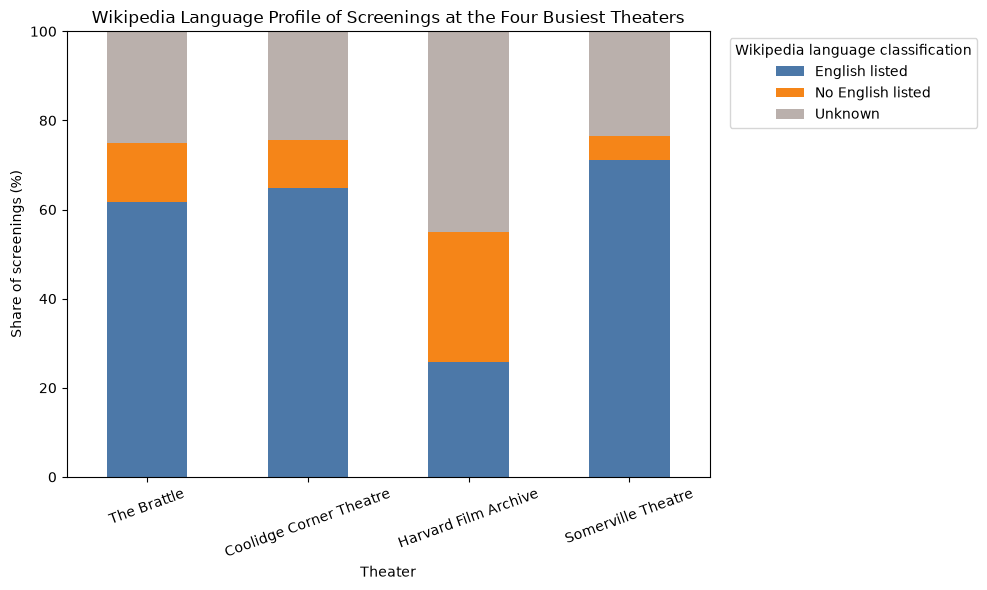

In [30]:
# your code here
top_four = df["theater"].value_counts().head(4).index

language_plot_data = df.loc[
    df["theater"].isin(top_four)
].copy()

language_share = pd.crosstab(
    language_plot_data["theater"],
    language_plot_data["language_group"],
    normalize="index"
) * 100

language_share = language_share.reindex(
    index=top_four,
    columns=[
        "English listed",
        "No English listed",
        "Unknown"
    ],
    fill_value=0
)

display.display(language_share.round(1))

ax = language_share.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=["#4C78A8", "#F58518", "#BAB0AC"]
)

ax.set_title(
    "Wikipedia Language Profile of Screenings "
    "at the Four Busiest Theaters"
)
ax.set_xlabel("Theater")
ax.set_ylabel("Share of screenings (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=20)
ax.legend(
    title="Wikipedia language classification",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

my question was if the 4 busiest theaters have diff languages- and thus maybe cater to different audiences. i used % in each theater to account for different total screening counts. we find the harvard film archive has the strongest intl orientaiton while brattle and coolidge have more English films this makes sense as the film archive may be less commercial and have more variety vs brattle and coolidge showing more mainstream films. unknown and multilingual means this should be treated as an approx comparison instead of a perfect measure of the film spoken language 

In [31]:
# your code here
ENRICHED_FILE = "data/movies_enriched.csv"

df.to_csv(
    ENRICHED_FILE,
    index=False
)

print(f"Saved {df.shape[0]} rows and {df.shape[1]} columns")
print(f"File: {ENRICHED_FILE}")
print(f"Size: {os.path.getsize(ENRICHED_FILE) / 1e6:.2f} MB")

assert len(df) == rows_before_merge
assert df.shape[1] >= 10

Saved 2335 rows and 13 columns
File: data/movies_enriched.csv
Size: 0.36 MB


In [32]:
grader.check("q8")

q8 results: All test cases passed!

### 8a. SQL — AC209A only (3 pts)

The DataFrame operations you've used all assignment — subset, aggregate, join, transform — are the same four verbs SQL speaks, and SQL is the dialect most of industry says them in (see the *DuckDB: SQL on files* supplemental). Pose one Q5-style analytical question about your enriched screening data and answer it with a **single SQL query** run via `duckdb` directly against `data/movies_enriched.csv`. Display the result and interpret it in 2–3 sentences. Prefer a question where SQL earns its keep (a grouped ranking, a window function, a multi-way aggregation).

In [33]:
# your code here
...

Ellipsis

*your answer here*

## Question 9: The decision — program Halloween weekend

<p>You now advise a consortium of the <b>four theaters with the most screenings</b> in your data. They want a coordinated plan for <b>Halloween weekend 2026 (Fri Oct 30 – Sun Nov 1)</b>: each theater programs a small slate, with the goal of maximizing <b>total ticket revenue across the consortium</b> — so the theaters should draw large audiences <i>without competing head-to-head for the same one</i>.</p>

Produce a recommendation, supported by your data. There is no single right answer; you are graded on the clarity of your reasoning and on whether the data you present actually supports the recommendation you make.

### 9.1 Theater personalities

**Identify the four theaters** and characterize their programming "personalities" (the audience each one's history suggests it draws): genre mix, film vintage, language profile — whatever you judge informative. **Profile at least two theaters in depth** (all four encouraged), with at least one supporting visualization.

,screenings,unique_films,median_year,median_runtime_min,language_known_pct,non_english_pct_among_known
theater,,,,,,
The Brattle,883,633,1986.0,103.0,74.9,17.5
Coolidge Corner Theatre,679,607,1992.0,105.0,75.7,14.2
Harvard Film Archive,348,280,1970.0,101.0,54.9,52.9
Somerville Theatre,212,188,1985.0,108.0,76.4,6.8


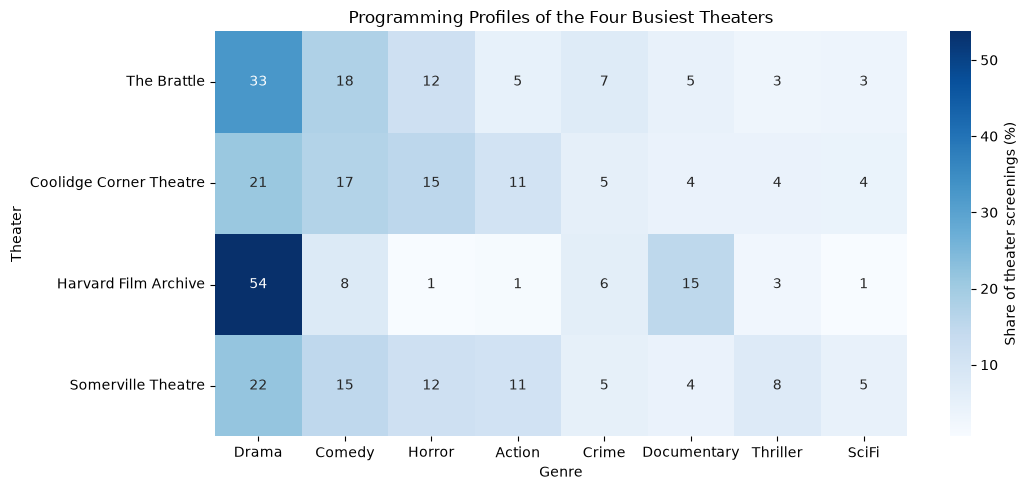

In [34]:
# your code here
top_four_theaters = (
    df["theater"]
    .value_counts()
    .head(4)
    .index
    .tolist()
)

profile = df.loc[
    df["theater"].isin(top_four_theaters)
].copy()

profile["runtime_min"] = (
    profile["runtime"].dt.total_seconds() / 60
)

profile["valid_year"] = profile["year"].where(
    profile["year"].between(1888, 2026)
)

profile["language_group"] = (
    profile["language_group"]
    .fillna("Unknown")
)

profile_summary = (
    profile
    .groupby("theater", observed=True)
    .agg(
        screenings=("title", "size"),
        unique_films=("title", "nunique"),
        median_year=("valid_year", "median"),
        median_runtime_min=("runtime_min", "median")
    )
    .reindex(top_four_theaters)
)

language_counts = pd.crosstab(
    profile["theater"],
    profile["language_group"]
).reindex(index=top_four_theaters, fill_value=0)

known_languages = language_counts.reindex(
    columns=["English listed", "No English listed"],
    fill_value=0
).sum(axis=1)

profile_summary["language_known_pct"] = (
    100
    * known_languages
    / language_counts.sum(axis=1)
)

profile_summary["non_english_pct_among_known"] = (
    100
    * language_counts.reindex(
        columns=["No English listed"],
        fill_value=0
    )["No English listed"]
    / known_languages.replace(0, pd.NA)
)

display.display(profile_summary.round(1))

top_profile_genres = (
    profile["genre"]
    .value_counts()
    .head(8)
    .index
)

profile_genre_share = pd.crosstab(
    profile["theater"],
    profile["genre"],
    normalize="index"
) * 100

profile_genre_share = profile_genre_share.reindex(
    index=top_four_theaters,
    columns=top_profile_genres,
    fill_value=0
)

plt.figure(figsize=(11, 5))
sns.heatmap(
    profile_genre_share,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    cbar_kws={"label": "Share of theater screenings (%)"}
)
plt.title("Programming Profiles of the Four Busiest Theaters")
plt.xlabel("Genre")
plt.ylabel("Theater")
plt.tight_layout()
plt.show()

the four busiest are brattle, coolidge, harvard film archive and somerville. we can see harvard film archive is most specialized with drama being the top type shown. >50% is drama and documentary is also popular. it also shows older films (median film year is older) showing the audience cares more about history/historical films as well as more academic cinema this maeks sense given its role as a film archive.wikipedia language also shows that it focuses on more academic exposure to films not just what is popular, with more languages shown but this has many missing info boxes limiting the accuracy of this comparison.

coolidge seems more event-oriented with more comedy horror and action movies as well as many marathons suggesting it may focus on community building and pop-culture

somerville appears quite similar to cooliedge but also has more thriller 

brattle focuses more on drama than cooliedge and somerville but far less than the film archive


### 9.2 Your draw proxy

You have no revenue data, so state explicitly what you will use as a stand-in for "how many people a film/genre draws at this theater" and defend it in a sentence or two.

In [35]:
# your code here
# Proxy 1: the percentage of a theater's historical listings
# assigned to each genre.
genre_draw_proxy = (
    profile
    .dropna(subset=["genre"])
    .groupby(["theater", "genre"], observed=True)
    .size()
    .rename("screenings")
    .reset_index()
)

genre_draw_proxy["share_within_theater"] = (
    genre_draw_proxy["screenings"]
    / genre_draw_proxy
        .groupby("theater")["screenings"]
        .transform("sum")
)

top_genre_proxy = (
    genre_draw_proxy
    .sort_values(
        ["theater", "share_within_theater"],
        ascending=[True, False]
    )
    .groupby("theater", group_keys=False)
    .head(5)
)

top_genre_proxy["share_within_theater"] *= 100

print("Top genre draw proxies:")
display.display(
    top_genre_proxy.sort_values(
        ["theater", "share_within_theater"],
        ascending=[True, False]
    ).round(1)
)

# Proxy 2: titles repeatedly programmed by the same theater.
title_draw_proxy = (
    profile
    .groupby(["theater", "title"], observed=True)
    .size()
    .rename("screenings")
    .reset_index()
)

top_title_proxy = (
    title_draw_proxy
    .sort_values(
        ["theater", "screenings"],
        ascending=[True, False]
    )
    .groupby("theater", group_keys=False)
    .head(5)
)

print("\nMost repeatedly programmed titles:")
display.display(top_title_proxy)

Top genre draw proxies:


,theater,genre,screenings,share_within_theater
6,Coolidge Corner Theatre,Drama,143,21.1
3,Coolidge Corner Theatre,Comedy,116,17.1
10,Coolidge Corner Theatre,Horror,105,15.5
0,Coolidge Corner Theatre,Action,72,10.6
4,Coolidge Corner Theatre,Crime,37,5.5
24,Harvard Film Archive,Drama,186,53.8
23,Harvard Film Archive,Documentary,53,15.3
21,Harvard Film Archive,Comedy,27,7.8
22,Harvard Film Archive,Crime,21,6.1
33,Harvard Film Archive,Thriller,9,2.6



Most repeatedly programmed titles:


,theater,title,screenings
523,Coolidge Corner Theatre,The Room,8
160,Coolidge Corner Theatre,Eraserhead,7
30,Coolidge Corner Theatre,Akira,4
253,Coolidge Corner Theatre,Jaws,4
502,Coolidge Corner Theatre,The Muppet Christmas Carol,4
790,Harvard Film Archive,Snow White,4
833,Harvard Film Archive,The Third Man,4
680,Harvard Film Archive,Floating Clouds,3
614,Harvard Film Archive,A Terra! The Cinema of Marta Mateus Program III,2
615,Harvard Film Archive,A Traveler's Needs,2


there is no revenue data so instead i assume if something is shown a lot by the theatre it was a financial success - i then pull on the genre's share of theater listing and whether the theater did reruns of a title. there are only a limited number of screens so you only rebook if you expect the audience to get more ; this is supply-side relying on what they estimate will sell well instead of ticket sales, but is the best we can get (we can assume they have experience running cinemas and know what audiences want)

### 9.3 The slates

Recommend **2–3 films (or film types)** for each theater you profiled, and at least a one-line programming direction for the others. Justify choices with your profiles and draw proxy, and explain how the slates avoid cannibalizing each other.

coolidge - we can have a movie marathon of horror-comedy movies for example watching the fear street trilogy with a halloween marathon as coolidge has a lot of horror/action programming. this is also more recent and more genz focused The Room was also popular so maybe doing rom-coms with a series like to all the boys i loved before could work as it is pop culture and would fit the demographic

harvard film archive - program restored silent film or early cinema horror, as it would fit the demographic of prefering older movies and stuff that is less pop/mainstream. maybe a documentary as well with rare archival footage as that would likely be popular instead of mainstream films they could also play international films and maybe have an associated cultural event

somerville could have slightly older but mainstream type science fiction or nostalgic horror-comedy with its broad genre history and marathon programming allowing for a halloween costume friendly type communla event

this separates the audiences as coolidge could be more genz focused with recent rom coms or horror comedies, harvard film archive has a more niche group with either international films or achival footage while somerville is more about nostalgia of older movies  for millenials etc

### 9.4 Uncertainties

At least two ways this analysis could mislead the consortium, and what data you'd want next.

screening frequency is supply-side focusing on programming supply decisions instead of actual success metrics of attendance and revenue; looking at concession revenue auditorium seat capacity ticket prices and occupancy and sales could be more helpful

the archive also has uneven temporal coverage so a theater that has more frequently captured data can look more active than one with missing snapshots but this is just a lack of data instead of actual information, it would be helpful to see complete internal schedules instead giving verified data

## Question 10: Reproducibility reflection, AI disclosure & data submission

### 10.1 Reproducibility reflection

A short paragraph or bullets: walk through your pipeline and identify what is **reproducible** (same result on every re-run, for anyone) and what is **brittle or non-reproducible** — and how you mitigated each risk. Consider at least: the live fetch (Q1), your HTML parsing (Q2), the Wayback snapshots (Q3), and the Wikipedia lookups & content (Q6–Q8). Also: the raw wiki cache is *deliberately excluded* from your submission (see 10.3) — what does that exclusion mean for the reproducibility of your Q8 columns?

the live fetch is not reproducible because the page will change every day. the way we solved this was having the cacje for the version we analyze

parsing will be deterministic therefore on the cache HTML but if the website changes its structure/DOM- as we saw with the legacy layout - the parsing will fail

the wayback portion is more reproducible because it has pnned capture timestamps and URL with the per-file guards and saves making interrupted downloads resumable, caching them so it doesnt have to be re-run. the response and parser checks stop error pages from being saved as data 

the wikipedia article titles and content can change- we put ID matching with numeric page IDs and rejected disambiguation pages

wikitext was cached during acquisition and the exraced language table was separately cached and merged with validation 
since the raw directory was excluded from submission the offline grader can reproduce q8 columns from the csv we saved but not rerun or audit the original language extraction independently wihtout downloading the pages again

### 10.2 AI disclosure

A few sentences: how you used AI tools on this assignment (which parts, what for) and — the part we grade — **what you did to verify their output** before signing off on it. There is no penalty for extensive AI use; there is a penalty for unverified submission.

I used chatgpt and codex to help with the wayback throttling problem. i was able to produce the parser for the modern format using the ideas in section and finding tags but used it toh elp adapt it to allow for legacy layouts. this helped me figure out to use cdx to help get metadata from the website wihtout needing to get every webpage 

it also helped me with padnas cleaning and duplicate handling

I would also send it some of the error messages for advice with debugging. 

To verify I inspired the parsed dictionaries to ensure they contained the right fields and compared it to the HTML of the website. I looked at parser reports and confirmed the wayback snapshots. in verifying I Found the duplicates i mentioned which i initialled missed with screening time and worked to fix that ; i also confirmed wikipedia merges preserve original screening rows and row-count assertions I looked at the successful and unsccuessful matches to get matching coverage. the otter tests also suggested i was correct 

### 10.3 Data submission

Run the provided manifest cell below. You will upload these files with your notebook so it can be re-run and graded *without any network access*. The full set must stay **under 25 MB** — this is why Q7 cached page content to disk instead of stuffing it in the DataFrame.

In [36]:
# --- PROVIDED CELL: submission manifest. Run before submitting; do not edit.
# Your submission = this notebook + every file listed below (data/wiki/ raw
# page cache is deliberately excluded). The set must total <= 25 MB.
SUBMISSION_FILES = sorted(
    glob.glob("data/html/*.html")     # live page + pinned snapshots
    + glob.glob("data/*.json")        # movies.json, wayback manifest, ...
    + glob.glob("data/*.csv")         # your derived caches / enriched table
)

assert SUBMISSION_FILES, "No data files found -- did the pipeline run?"
assert any("movies_enriched" in f for f in SUBMISSION_FILES), \
    "data/movies_enriched.csv is required (Q8)."

total_mb = sum(os.path.getsize(f) for f in SUBMISSION_FILES) / 1e6
for f in SUBMISSION_FILES:
    print(f"{os.path.getsize(f)/1e6:8.2f} MB  {f}")
print(f"{'-'*40}\n{total_mb:8.2f} MB  total ({len(SUBMISSION_FILES)} files)")

assert total_mb <= 25, "Submission exceeds the 25 MB budget!"
print("\nWithin the 25 MB budget -- ready to submit.")

    0.23 MB  data/html/screenboston.html
    0.01 MB  data/html/snapshot_20240328.html
    0.26 MB  data/html/snapshot_20240524.html
    0.16 MB  data/html/snapshot_20240621.html
    0.24 MB  data/html/snapshot_20240803.html
    0.25 MB  data/html/snapshot_20240904.html
    0.37 MB  data/html/snapshot_20240926.html
    0.22 MB  data/html/snapshot_20241101.html
    0.16 MB  data/html/snapshot_20241206.html
    0.17 MB  data/html/snapshot_20250105.html
    0.27 MB  data/html/snapshot_20250131.html
    0.19 MB  data/html/snapshot_20250217.html
    0.17 MB  data/html/snapshot_20250326.html
    0.20 MB  data/html/snapshot_20250428.html
    0.18 MB  data/html/snapshot_20250616.html
    0.17 MB  data/html/snapshot_20250622.html
    0.25 MB  data/html/snapshot_20250813.html
    0.30 MB  data/html/snapshot_20250903.html
    0.22 MB  data/html/snapshot_20250924.html
    0.23 MB  data/html/snapshot_20251021.html
    0.24 MB  data/html/snapshot_20251127.html
    0.12 MB  data/html/snapshot_2025121

In [37]:
grader.check("q10_3")

q10_3 results: All test cases passed!

## Wrap-up

<div class="alert alert-info" style="color: #4a4a4a; background-color: #fbe8ff; border-color: #eed4db; border-width: 1px; border-radius: 3px; padding: 10px;">

* Which aspect(s) of the assignment did you find most challenging — conceptually or in implementation? Any remaining questions?

* How many hours did you spend on this assignment? Store an int or float in `hours_spent_on_hw` (if you worked in a group, report the average per person).

</div>

In [38]:
hours_spent_on_hw = 7

In [39]:
grader.check("wrapup")

wrapup results: All test cases passed!

In [40]:
notebook_end = time.time()
print(f"It took {(notebook_end - notebook_start)/60:.2f} minutes for this notebook to run")

It took 0.61 minutes for this notebook to run


🌈 **This concludes HW1. Thank you!**